In [1]:
# Core libraries
import json
import logging
import math
from math import exp, radians, sin, cos, sqrt, atan2
import random
import re
import time
from datetime import datetime, timedelta
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Geospatial & geometry
import geopandas as gpd
import networkx as nx
%pip install osmnx
import osmnx as ox
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from shapely.geometry import LineString, Point, box
from shapely.ops import split

# Static visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
from matplotlib import rcParams
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.offsetbox import TextArea, HPacker, AnchoredOffsetbox
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# Interactive and mapping visualization
%pip install contextily
import contextily as ctx
import folium
from folium.plugins import HeatMap, TimestampedGeoJson
from branca.colormap import linear

# Web driver
%pip install selenium
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options

# Fonts
%pip install pyfonts
from pyfonts import load_google_font, load_font

# Statistics and modeling
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler

# Widgets and display
import ipywidgets as widgets
from IPython.display import display, clear_output

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## First Map: small section of the city of Madrid
We use a small part of Madrid - specifically the Las Letras/Huertas neighborhood - and generate the pedestrian street network within a defined bounding box.

We choose not to simplify the graph (`simplify = False`) so we retain all edges and nodes exactly as they appear in OpenStreetMap. This ensures a higher level of detail, keeping intermediary nodes such as curves and bends.

The output (`G`) is a MultiDiGraph,meaning:
* It is a directed graph
* Multiple edges can exist between the same pair of nodes (for example, one edge for each direction)

The graph represents the street network and includes:
*   Nodes: each node represents a geographical point (an intersection or a curve in the road). Since we are using `simplify=False`, the graph includes many more intermediate points.

Each node has different attributes:

* `x` and `y` are the longitude and latitude
* `street_count` is the number of streets connected to the node
* `highway` is the type of node or intersection

Each edge represents a street segment between two nodes. Attributes include: the `name`, `length`, `geometry` of the segment, as well as `highway` and `oneway`, which describe the type of segment and its directionality.

We use `network_type='walk'`to extract the pedestrian street network. This includes the following highway types: footway, pedestrian, path, steps, residential, living_street, service, cycleway ande road (Note that cycleway and road are often included for crossings and walkways).


> For more information on `network_type='walk'`visit [this Stack Overflow article](https://stackoverflow.com/questions/79271245/osmnx-python-network-type-filters )


## Get origin and destination points to get a relative map

To make the route calculation more intuitive, we have developped a simple interface to search for a route between two points based on their addresses.

We first define the Geocoding Function using the Nominatim service, a geocoding service provided by OpenStreetMap, which transforms addresses into geographic coordinates.

In [2]:
geolocator = Nominatim(user_agent="safe_route_colab", timeout=10) # 10 seconds before failing

# Controled usage of Nominatim service
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1,
    max_retries=3,
    error_wait_seconds=2.0,
)

# Helper: if one of the two adresses is wrong, which one?
def get_coordinates(address):
    """
    Returns (lat, lon) or None if not found.
    Respects OSM usage policy (1 q/sec) and retries on read timeouts.
    """
    try:
        location = geocode(address, exactly_one=True, addressdetails=True)
        addr = location.raw.get("address", {})
        municipality = (
            addr.get("city") 
            or addr.get("town") 
            or addr.get("village") 
            or addr.get("municipality")
        )
    except Exception as e:
        print(f"⚠️ Geocoding error for '{address}': {e}")
        return None

    if location:
        return (location.latitude, location.longitude, municipality)
    else:
        print(f"❌ Address not found: {address}")
        return None

### Insert Origin and Destination address to get coords

In [3]:
origin_input = widgets.Text(
    value='Via Trasea, Padova',
    placeholder='Enter origin address',
    description='Origin:',
    layout=widgets.Layout(width='90%')
)
destination_input = widgets.Text(
    value='Via Beato Luca Belludi, 27-5, Padova',
    placeholder='Enter destination address',
    description='Destination:',
    layout=widgets.Layout(width='90%')
)
search_button = widgets.Button(description="Get coordinates")
output = widgets.Output()

# Button
def on_search_click(b):
    global origin_coords, destination_coords
    with output:
        clear_output()
        o_addr = origin_input.value
        d_addr = destination_input.value
        origin_coords = get_coordinates(o_addr)
        destination_coords = get_coordinates(d_addr)
        if origin_coords and destination_coords:
            if abs(origin_coords[0] - destination_coords[0]) > 0.1 or abs(origin_coords[1] - destination_coords[1]) > 0.1:
                print(f"❌ Origin and destination are too far, please insert nearer points")
            else:
                print(f"✅ Origin:      {o_addr!r} → {origin_coords}")
                print(f"✅ Destination: {d_addr!r} → {destination_coords}")
        else:
            print("❌ One or both addresses could not be found.")

search_button.on_click(on_search_click)

display(widgets.VBox([
    origin_input,
    destination_input,
    search_button,
    output
]))

### Creating the map based on the origin and destination coords

In [22]:
# Get lan and lon from coords
origin_lat, origin_lon, origin_municipality = origin_coords
destination_lat, destination_lon, destination_municipality = destination_coords


# Create margin in the map
if origin_lat > destination_lat:
    corner1_lat = origin_lat + 0.01
    corner2_lat = destination_lat - 0.01
else:
    corner2_lat = origin_lat - 0.01
    corner1_lat = destination_lat + 0.01

if origin_lon > destination_lon:
    corner1_lon = origin_lon + 0.01
    corner2_lon = destination_lon - 0.01
else:
    corner2_lon = origin_lon - 0.01
    corner1_lon = destination_lon + 0.01

# Check for too little maps, this prevents errors in map generation
if abs(corner1_lat - corner2_lat) < 0.03:
    corner1_lat += 0.02
    corner2_lat -= 0.02
if abs(corner1_lon - corner2_lon) < 0.03:
    corner1_lon += 0.02
    corner2_lon -= 0.02

bbox = (corner2_lon, corner2_lat, corner1_lon, corner1_lat)  # west, south, east, north)
G = ox.graph_from_bbox(bbox, network_type='bike', simplify=False) # download graph

We now convert the graph into two GeoDataFrame: one for nodes and one for edges. This makes it easier to work with the data using pandas and geospatial tools.

In the nodes dataset each row represents a specific point in the street network. Key columns include:
*   x and y: longitude and latitude
*   street_count: how many streets meet at this node
*   geometry: a `shapely.geometry.Point`, which represents a single point in space
*   tags for: highway (traffic_signals, crossing, elevator, give_way, etc), railway (subway_entrance) and junction (yes)

In the edges datafrane each row represents a street segment, with full geometric and attribute information:
*   u and v which are the starting and ending node ID of the edge.
*   key: counter used for multiple edges between the same nodes.
*   osmid: OSM ID of the way
*   access: access restrictions
*   highway: type of street
*   lanes: nymber of lanes
*   maxspeed: speed limit
*   oneway: if the edge is one-way or not
*   reversed: if the edge was inverted compared to how it appears in OSM
*   length: in meters
*   name
*   service: type of service road
*   tunnel: true or false
*   geometry: `shapely.geometry.LineString`

In [23]:
nodes, edges = ox.graph_to_gdfs(G)

## Cleaning of edge dataframe

Before continuing, we need to clean the `edges` GeoDataFrame. This is a crucial step, as we are developing an application designed to help women find safe and walkable routes. Therefore, not all segments in the OpenStreetMap data are suitable for pedestrian routing.

A key attribute for determining whether a path is usable is the `access` field, which describes the legal accesibility of a street segment. We won't be using the following segments: `no`, `private`, `discouraged`, `customers`, `agricultural`, `forestry`, `military`, `permit`

> For more information on access attribute visit the [Key:access wiki page](https://wiki.openstreetmap.org/wiki/Key:access)

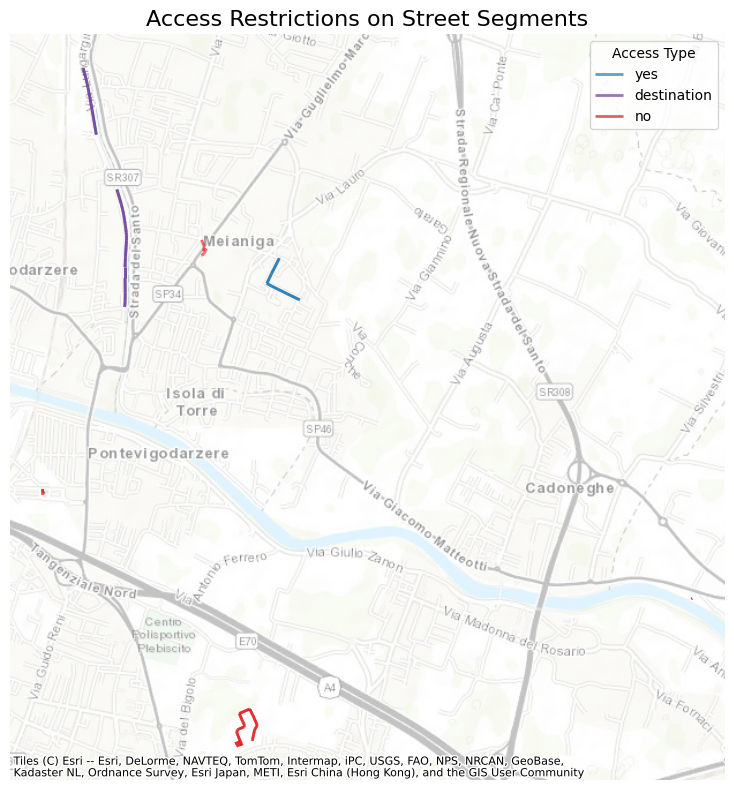

In [24]:
# Reproject your edges GeoDataFrame to Web Mercator once:
edges_web = edges.to_crs(epsg=3857)

# Define color map for the relevant access types:
color_map = {
    'yes': '#1f78b4',
    'permissive': '#33a02c',
    'destination': '#6a3d9a',
    'delivery': '#ff7f00',
    'no': '#e31a1c'
}

# Plot each type that actually appears in the data:
fig, ax = plt.subplots(figsize=(12, 8))
for access_type, color in color_map.items():
    subset = edges_web[edges_web['access'] == access_type]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            linewidth=2,
            alpha=0.7,
            label=access_type
        )

# Add a basemap:
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTopoMap,
    crs=edges_web.crs,
    alpha=0.6
)

# Final touches:
ax.set_title("Access Restrictions on Street Segments", fontsize=16)
ax.legend(title="Access Type")
ax.axis("off")
plt.tight_layout()
plt.show()


In [25]:
# Let's check what is present now
edges['access'].unique()

array([nan, 'destination', 'no', 'yes'], dtype=object)

In [26]:
restricted = [
    'no', 'private', 'discouraged', 'customers',
    'agricultural', 'forestry', 'military', 'permit'
]

to_remove = [
    (u, v, k)
    for u, v, k, data in G.edges(keys=True, data=True)
    if data.get('access') in restricted
]

We eliminate the edges that contain forbidden or unsuitable access values from the graph `G`.

In [27]:
# Cleaning edges
G.remove_edges_from(to_remove)

# Cleaning nodes
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

# Now we regenerate the nodes and edges
nodes, edges = ox.graph_to_gdfs(G)

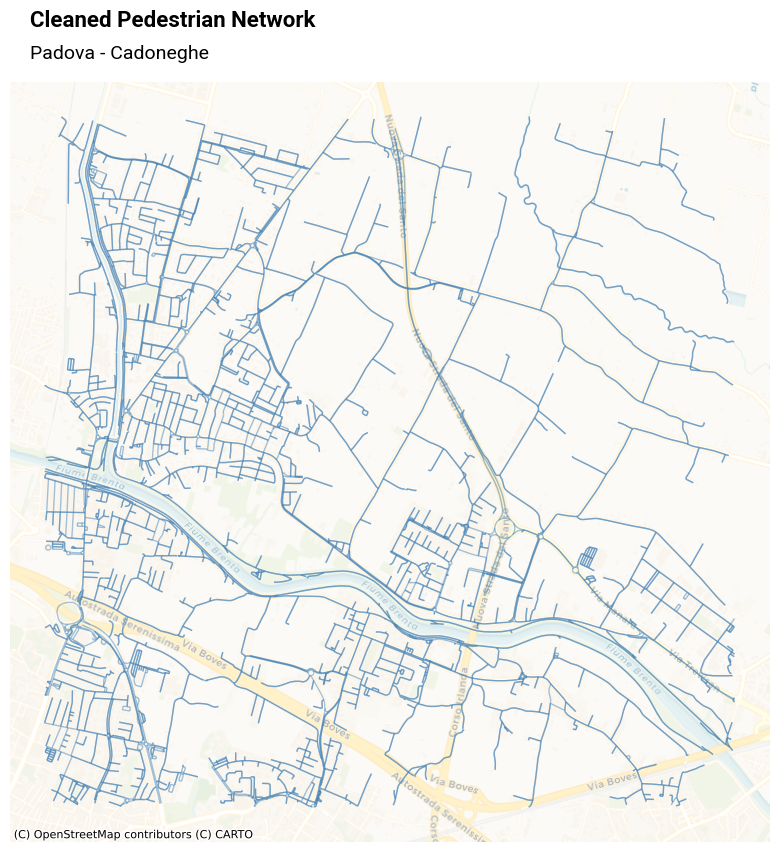

In [28]:
# Reproject edges to Web Mercator for the basemap
edges_web = edges.to_crs(epsg=3857)

# Plot the cleaned network
fig, ax = plt.subplots(figsize=(12, 8))
edges_web.plot(
    ax=ax,
    linewidth=1,
    color='steelblue',
    alpha=0.5
)

# Add a basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges_web.crs,
    alpha=0.6
)

# Title
bold = load_google_font("Roboto", weight="bold")
fig.text(x=0.2, y=1.02, s="Cleaned Pedestrian Network", size=16, font=bold)
regular = load_google_font("Roboto")
if origin_municipality == destination_municipality:
    fig.text(x=0.2, y=0.98, s=origin_municipality, size=14, font=regular)
else:
    fig.text(x=0.2, y=0.98, s=origin_municipality+" - "+destination_municipality, size=14, font=regular)

ax.axis("off")

# Margins
plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0)
plt.savefig("network_clean.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()

## Develop of the security map


### 1. Intersections as a Safety Factor

One concern in the context of safe pedestrian routing is the length of street segments (edges). A very long edge may imply a lack of nearby intersections or escape points, making it harder for a person to change direction or seek help if they feel unsafe.

It's important to note that in our network structure, each intersection is a node, and edges represent the street segments between them. For this reason, we don't consider it necessary to artificially subdivide longer edges. However, we acknowledge that long, uninterrupted segments may reduce a user's sense of security. As a result, we propose assigning a penalty to longer edges in the routing algorithm, reducin their priority when calculating the safest route.

We set a threshold of 100 meters to flag an edge as "long". A person average walking speed is approximatly 1.4 meters per second (about 5 kilometers per hour). So 100 meters takes roughly 1 minute and 10 seconds, which is a significant amount of time to be in an exposed space without a nearby intersection

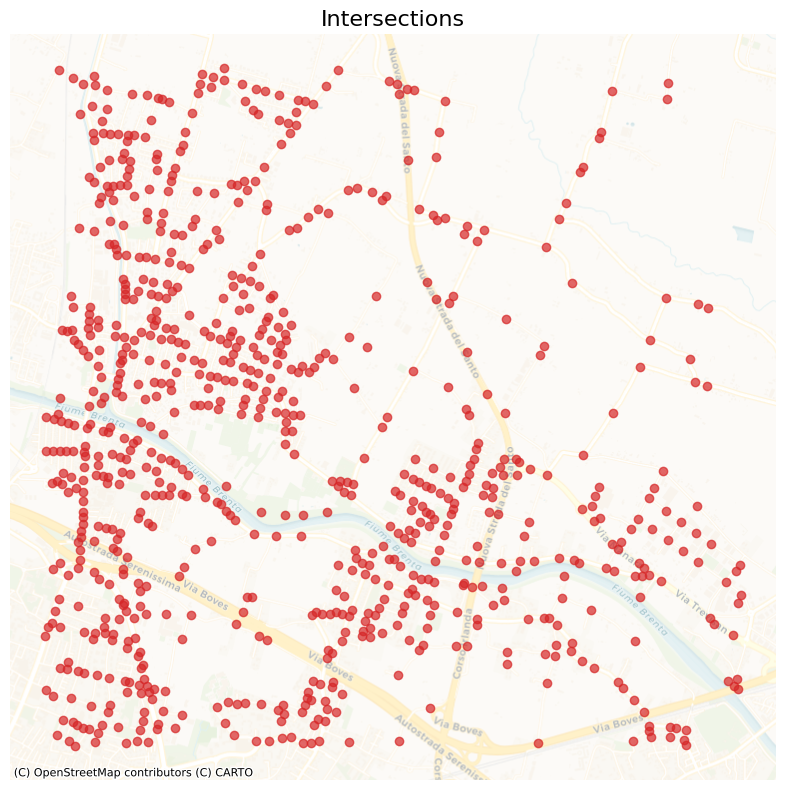

In [29]:
edges_web = edges.to_crs(epsg=3857)

# Simplify the graph to remove middle points
simple_G = ox.simplify_graph(G).copy()
simple_G = ox.project_graph(simple_G)

# Consolidation for roundabouts
consolidate_G = ox.consolidate_intersections(simple_G, tolerance=15, node_attr_aggs='degree')

consolidate_nodes, consolidate_edges = ox.graph_to_gdfs(consolidate_G)
consolidate_nodes = consolidate_nodes.to_crs(epsg=3857)

# Get intersections by nodes degree
degree = consolidate_G.degree
consolidate_nodes["degree"] = consolidate_nodes.index.map(degree)

intersections = consolidate_nodes[consolidate_nodes["degree"] >= 3].copy()

# Plot them in red on top of a basemap
fig, ax = plt.subplots(figsize=(12, 8))
intersections.plot(
    ax=ax,
    color='#d62728',

    alpha=0.7
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges_web.crs,
    alpha=0.6
)

ax.set_title("Intersections", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

As discussed earlier, longer street segments can cotribute to a greater sense of insecurity. To account for this in our model, we implement a length-based penalty so that the roing algorithm treats longer edges as potentially more dangerous.

We design a function that asigns this penalty using a non-linear formula. The idea is to penalize longer segments more heavily than shorter ones. Specifically, we normalize each edge's length by dividing it by the maximum edge length in the map, and then raise this ratio to the 1.5 power to accentutate the penalty for longer streets.

The formula used is:

$$
\text{penalty} = \left( \frac{\text{degree}}{\text{max\_degree}} \right)^1.5
$$

First, we calculate maximum edge length in the current network.

Then, we define a function (`assign_length_penalty`) that:
1.   Normalizes each edge's length by dividing it by the maximum length. This scales all values to a range between 0 and 1.
2.    Applies quadratic scaling by squaring the normalized length. This ensures that longer segments are penalized more sharply, while short segments receive minimal penalty.
3.    Stores the result as an edge attribute named `length_penalty`


Notes: changed to degree_penalty based on the number on streets that crosses on the same node, the function is similar to the length_penalty but instead of length now uses degree of nodes

In [30]:
# Maximum node degree for our current network
max_degree = intersections['degree'].max()

def degree_penalty(degree, max_degree=max_degree, exponent=1.5):
    """
    Assigns a non-linear penalty that increases sharply with degree.
    - Low degree → near 0 penalty
    - High degree → penalty approaches 1
    """
    norm = degree / max_degree
    return min(norm ** exponent, 1.0) # for rounding errors


# Applying the function to the nodes DataFrame
intersections['degree_penalty'] = intersections['degree'].apply(degree_penalty)

# And into the G graph
for u, data in G.nodes(data=True):
    data['degree_penalty'] = degree_penalty(data.get('degree', 0))
    

Bring degree_penalty function to edges similarly to incident_penalty

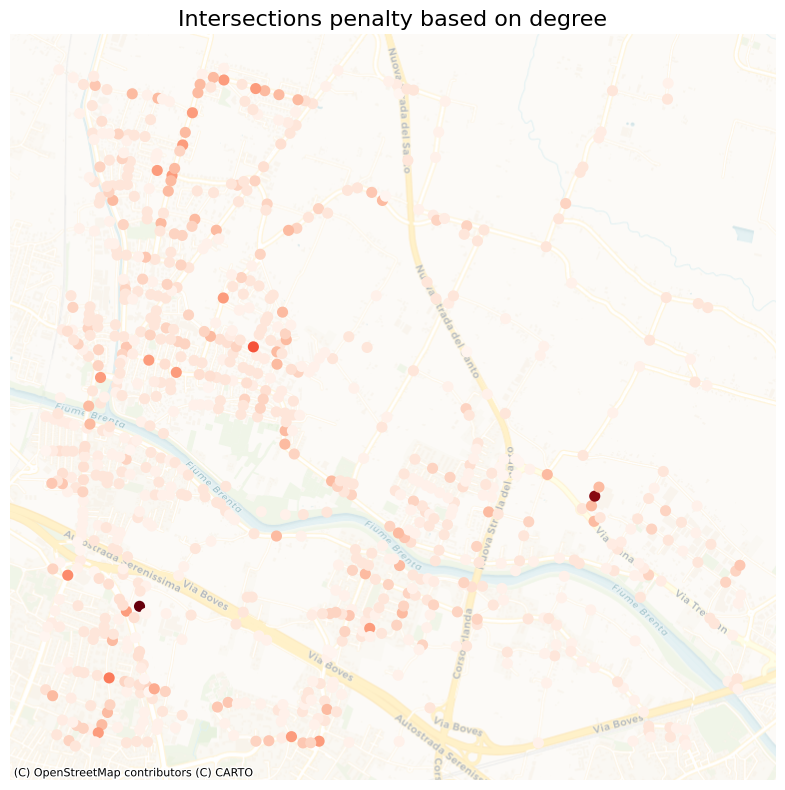

In [31]:
edges_web = edges.to_crs(epsg=3857)

# Plot, coloring by the new penalty column
fig, ax = plt.subplots(figsize=(12, 8))
intersections.plot(
    ax=ax,
    column='degree_penalty',
    cmap='Reds',
    linewidth=2,
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges_web.crs,
    alpha=0.6
)

ax.set_title("Intersections penalty based on degree", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

### Bring intersections penalty effects on streets
Based on incidents penalty application

In [32]:
edges = edges.to_crs(epsg=3857)
intersections = intersections.to_crs(epsg=3857)

# Initialize penalty column
edges['intersections_penalty'] = 0.0

# Penalty function. Assings penalty based on distance, 1 if distance = 0 (place of the intersection)
# and 0 if distance is further the limit. In between there is a linear decay
def intersections_penalty(dist, limit=100):
    return max(0, 1 - dist/limit)

# Calculate penalty from each intersection to nearby streets, if they are several, the penalties are added
for idx, row in intersections.iterrows():
    pt_geom = row.geometry
    deg_pen = row['degree_penalty']
    distances = edges.geometry.distance(pt_geom)
    edges['intersections_penalty'] += distances.apply(intersections_penalty)*deg_pen

# Now we normalize from 0 to 1
scaler = MinMaxScaler((0, 1))
edges['intersections_penalty'] = scaler.fit_transform(
    edges[['intersections_penalty']]
)

print("Intersections Penalty – summary stats:")
print(edges['intersections_penalty'].describe())

Intersections Penalty – summary stats:
count    20021.000000
mean         0.117293
std          0.096273
min          0.000000
25%          0.046809
50%          0.104537
75%          0.170181
max          1.000000
Name: intersections_penalty, dtype: float64


C:\Users\lucac\AppData\Local\Temp\ipykernel_12232\1750614903.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', framealpha=0.8)


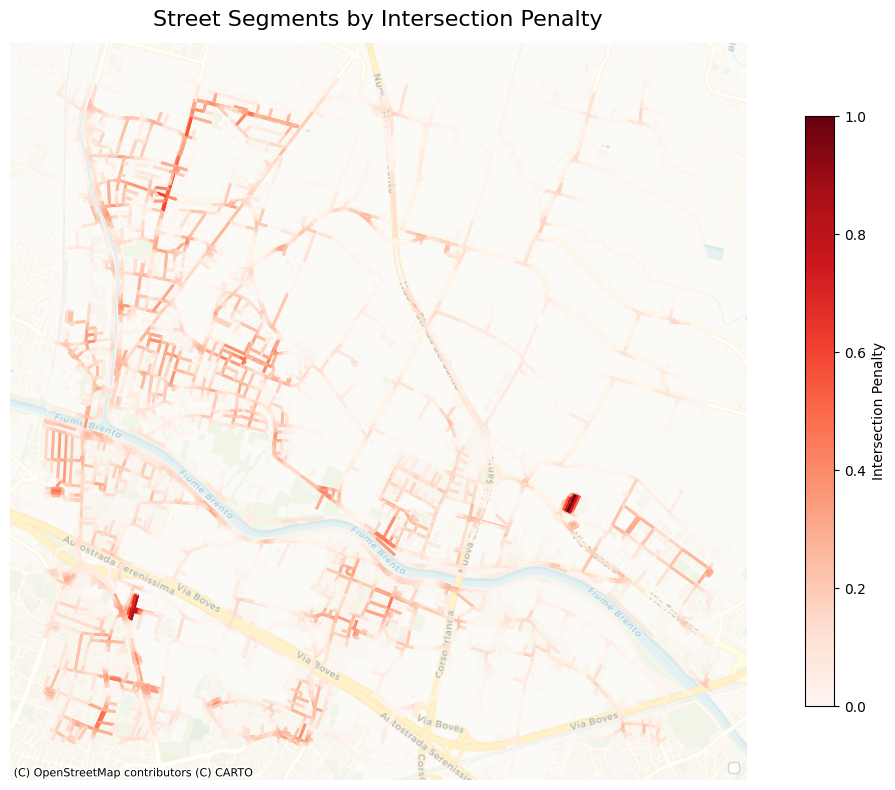

In [33]:
edges = edges.to_crs(epsg=3857)
intersections = intersections.to_crs(epsg=3857)

# Network + Intersections penalty
fig, ax = plt.subplots(figsize=(12, 8))
edges.plot(
    ax=ax,
    column='intersections_penalty',
    cmap='Reds',
    linewidth=2,
    legend=True,
    legend_kwds={
        'label': "Intersection Penalty",
        'shrink': 0.8
    }
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.6
)

ax.set_title("Street Segments by Intersection Penalty", fontsize=16, pad=12)
ax.axis('off')
ax.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

### 2.1. Active Reports of Street Sexual Harassment

The main use of this algorithm is to generate safe walking routes that take into account reported incidents of street sexual harassment. As a first approximation, we simulate these reports by randomly generating incidents on the map.

To ensure incidents are not placed near the map boundaries (where routing may be less stable), we apply a buffer and use a reduced section of the map for this simulation.

We begin by generating 5 random incidents. A loop is used to:
*  Randomly select and edge from the network where the incident will be located,
*  Randomly determine the location along that edge where the incident occurs.


In [34]:
edges = edges.to_crs(epsg=3857)

# Get bounds of the current walkable network
minx, miny, maxx, maxy = edges.total_bounds  # (west, south, east, north)

# Shrink the box approximatly 15% from each side to define a smaller "incident area"
margin_x = (maxx - minx) * 0.1
margin_y = (maxy - miny) * 0.1

incidents_box_geom = box(
    minx + margin_x,
    miny + margin_y,
    maxx - margin_x,
    maxy - margin_y
)

edges_for_incidents = edges[edges.intersects(incidents_box_geom)]

## Get points from the web page

In [48]:
# Functions to get points
def find_and_assign(path):
    try:
        WebDriverWait(driver, 5).until(
            EC.presence_of_element_located((By.XPATH, path))
        )
        return driver.find_element(By.XPATH, path)
    except:
        print("Element not found", path)

def get_incidents_map(municipality):
    # Get and click drop-down menu
    drop_down = find_and_assign("//div[@id='tabZoneId10']//span[@class='tabComboBox tab-ctrl-formatted-widget tab-ctrl-formatted-darker-border-hover tab-ctrl-formatted-darker-border-focus tabComboStdTheme tabComboBoxNoIcon tiledContent']")
    drop_down.click()
    
    # Get and click check-box
    check_all = find_and_assign("//input[@name='FI_federated.1eckria1b6k7771bxzlfa1c7pfdu,none:COMUNE:nk13834208949810012203_14646624410065774129_(Tutti)']")
    check_all.click()

    # Filter by municipality
    incidents_filter = find_and_assign("//div[@class='CFOuterContainer tabMenuComboDropdownTheme tab-ctrl-formatted-widget tab-darkBackground CFAll']//textarea[@title='Cerca (Immetti)']")
    incidents_filter.send_keys(municipality)
    municipality_filter = find_and_assign("//div[@class='CFOuterContainer tabMenuComboDropdownTheme tab-ctrl-formatted-widget tab-darkBackground CFAll']//a[@title='"+municipality+"']/../input")
    municipality_filter.click()
    apply_button = find_and_assign("//div[@class='CFOuterContainer tabMenuComboDropdownTheme tab-ctrl-formatted-widget tab-darkBackground CFAll']//button[@title='Applica']")
    apply_button.click()
    time.sleep(3)
    
    ## Go back to the map
    driver.find_element(By.TAG_NAME, "body").click()

    # Zoom on the selected municipality
    map_filter_button = find_and_assign("//button[@title='Mappa di ricerca']")
    map_filter_button.click()

    map_filter = find_and_assign("//input[@class='tabTextInputViewInputElement']")
    map_filter.send_keys(municipality)
    map_filter.send_keys(Keys.ENTER)
    time.sleep(2)

    # Return the image
    driver.save_screenshot("incidents_map_"+municipality+".png")

    driver.refresh()

In [49]:
# Open web page, options to not open the page in the screen
options = Options()
options.add_argument("--window-size=1000,800")
options.add_argument("--headless=new")

driver = webdriver.Chrome(options=options)
driver.get("https://public.tableau.com/views/Dashboard5MAPPADEGLIINCIDENTICICLISTICIAnni2022e2023/CiclistiFeriti?%3Adisplay_static_image=y&%3Aembed=true&%3Aembed=y&%3Alanguage=it-IT&%3AshowVizHome=n&%3AapiID=host0#navType=0&navSrc=Parse")

# Load web page
try:
    WebDriverWait(driver, 20).until(
        EC.presence_of_element_located((By.XPATH, "//div[@id='tabZoneId11']"))
    )
    time.sleep(3)
except:
    print("Error in web page loading")
    driver.quit()

# Get incidents map to get points coordinates
if(origin_municipality==destination_municipality):
    get_incidents_map(origin_municipality)
else:
    get_incidents_map(origin_municipality)
    get_incidents_map(destination_municipality)

driver.quit()

In [ ]:
edges = edges.to_crs(epsg=3857)
incidents = incidents.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot the street network
edges.plot(
    ax=ax,
    color='#4682B4',    # steelblue
    linewidth=1.2,
    alpha=0.6,
    label='Street Network'
)

# Overlay the incident points
incidents.plot(
    ax=ax,
    color='#c0392b',    # deep red
    edgecolor='none',
    markersize=30,
    zorder=5,
    label='Incidents'
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.7
)

ax.set_title("Street Network with Incidents", fontsize=16, pad=12)
ax.axis('off')
ax.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

NameError: name 'incidents' is not defined

We consider it reasonable to assume that reported incidents of harassment affect not only the street segment where they occur, but also nearby segments - either adjacent edges or those within a certain radius.

To account for this spatial influence, we develop a penalty function that assigns risk to nearby edges based on their proximity to incidents.

We begin by initializing a new column (`incident_penalty`), in the `edges`GeoDataFrame and set all values to 0.

We then define a penalty function that assigns values based on distance:
*   A penalty of 1.0 if the edge is within 30 meters of the incident,
*   A penalty of 0.5 if the edge is within 30 to 60 meters,
*   A penalty of 0 if the edge is more than 60 meters away.

For each incident, we compute the distances to all edges and assign penalties accordingly. If an edge is affected by multiple incidents, it accumulates penalties - the values are summed rather than overwritten.

This simulation represents a snapshot of recent incidents, such as those reported in the last few hours. These "active" events reflect immediate risk and are treated as the most urgent input in the routing algorithm. In contrast, the next section incorporates historical incident patterns to detect streets witha longer-term risk profile.

In [ ]:
print(edges.columns)

Index(['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length',
       'lanes', 'junction', 'bridge', 'width', 'ref', 'service', 'tunnel',
       'access', 'est_width', 'geometry', 'intersections_penalty'],
      dtype='object')


In [ ]:
edges = edges.to_crs(epsg=3857)
incidents = incidents.to_crs(epsg=3857)

# Initialize penalty column
edges['incident_penalty'] = 0.0

# Penalty function. Assings penalty based on distance, 1 if distance = 0 (place of the incident)
# and 0 if distance is further the limit (100). In between there is a linear decay
def incident_penalty(dist, limit=100):
    return max(0, 1 - dist/limit)

# Calculate penalty from each incident to nearby streets, if they are several, the penalties are added
for pt in incidents.geometry:
    distances = edges.geometry.distance(pt)
    edges['incident_penalty'] += distances.apply(incident_penalty)

# Now we normalize from 0 to 1

scaler = MinMaxScaler((0, 1))
edges['incident_penalty'] = scaler.fit_transform(
    edges[['incident_penalty']]
)

print("Incident Penalty – summary stats:")
print(edges['incident_penalty'].describe())

Incident Penalty – summary stats:
count    76681.000000
mean         0.006170
std          0.047945
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: incident_penalty, dtype: float64


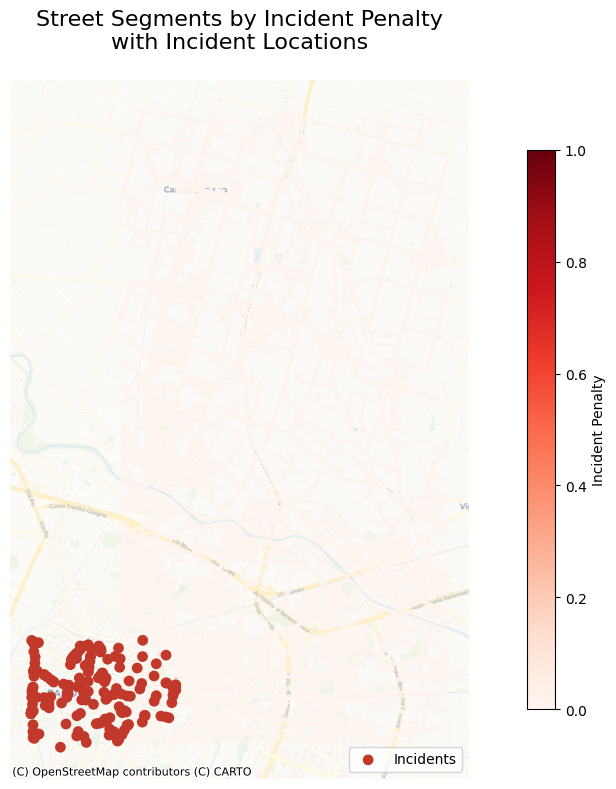

In [ ]:
edges = edges.to_crs(epsg=3857)
incidents = incidents.to_crs(epsg=3857)

# Network + Incident penalty
fig, ax = plt.subplots(figsize=(12, 8))
edges.plot(
    ax=ax,
    column='incident_penalty',
    cmap='Reds',
    linewidth=2,
    legend=True,
    legend_kwds={
        'label': "Incident Penalty",
        'shrink': 0.8
    }
)

# Incident points
incidents.plot(
    ax=ax,
    color='#c0392b',   # deep red
    edgecolor='none',
    markersize=10,
    label='Incidents',
    zorder=5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.6
)

ax.set_title("Street Segments by Incident Penalty\nwith Incident Locations", fontsize=16, pad=12)
ax.axis('off')
ax.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

### 2.2. Historical risk from street harassment: time-weighted simulation

While Section 2.1. focused on active incidents that represent immediate risk, here we introduce a historical layer of risk based on past incidents. The aim is to highlight streets that are repeatdly affected over time, which could indicate structural or environmental insicurity.

We simulate a two-week period of incidents, capturing recurring patterns in space and time. To emphasize recency, we will apply a time-decay model so that more recent incidents contribute more heavily to the final risk score.

We generate a map of incidents every six hours, resulting in 56 time intervals. At each timestamp, we simulate a variable number of incidents using nighttime intervals (between 22:00 and 06:00) are modeled with a higher incident average.

To add realistic variation, the number of incidents at each time is drawn from a Poisson distribution centered around the expected average.

In [ ]:
edges = edges.to_crs(epsg=3857)

# Define time bins: every 6 h over 14 days
start = datetime(2025, 6, 1)
timestamps = [start + timedelta(hours=6*i) for i in range(14*4)]

# Simulate “incidents” at random nodes per time bin
hist_points = []
hist_times  = []

for t in timestamps:
    # rate by hour
    lam = 22 if (t.hour >= 22 or t.hour < 6) else 15
    n = np.random.poisson(lam)
    if n == 0:
        continue

    # sample n segments (with replacement)
    segs = edges.sample(n=n,
                        replace=True,
                        weights=edges['length'])
    # pick a uniformly random point along each
    pts  = segs.geometry.apply(
        lambda line: line.interpolate(random.random(), normalized=True)
    )
    hist_points.extend(pts.tolist())
    hist_times .extend([t]*len(pts))

df_hist = gpd.GeoDataFrame(
    {'timestamp': hist_times},
    geometry=hist_points,
    crs=edges.crs
)

To capture the fading influence of older incidents we use an exponential decay function. Each incident is assigned a time-weighted value using an exponential decay function:

$$
\text{weight} = e^{-\lambda \cdot \Delta t}
$$

Where Δt is the time since the incident (in days), and 𝜆 is a decay rate. This function ensures that recent incidents have more influence, while older ones gradually lose importance.

For example, with 𝜆 = 0.3:

*   An incident from 1 day ago has a weight of ~0.74,
*   From 5 days ago, ~0.22,
*   From 10 days ago, ~0.05.

This allows us to combine frequency and recency into a single, dynamic risk score for each node.


In [ ]:
nodes_gdf = ox.graph_to_gdfs(G, nodes=True, edges=False).to_crs(epsg=3857)

# We assign each incident to its nearest node and compute the distance
df_hist = (
    gpd.sjoin_nearest(
        df_hist,
        nodes_gdf[['geometry']],
        how='left',
        distance_col='dist_to_node'
    )
    # after the join, the node ID is in osmid_right
    .rename(columns={'osmid': 'node'})
)


# Reference time: latest timestamp
ref = df_hist["timestamp"].max()

# Compute recency weights (exponential decay)
df_hist['weight'] = np.exp(
    -0.3 * ((ref - df_hist['timestamp']).dt.total_seconds() / 86400)
)

# Sum weights per node
node_risk = (df_hist
    .groupby('node')['weight']
    .sum()
    .reset_index(name='incident_weight')
)

# Normalize to [0,1]
node_risk["risk_score"] = MinMaxScaler()\
    .fit_transform(node_risk[["incident_weight"]])

In [ ]:
edges = edges.to_crs(epsg=3857)

# Compute the historical penalty per edge by averaging its endpoints’ risk
risk_map = node_risk.set_index('node')['risk_score'].to_dict()
edges['historical_penalty'] = [
    (risk_map.get(u,0) + risk_map.get(v,0)) / 2
    for u, v, _ in edges.index
]

# Normalization
scaler = MinMaxScaler((0, 1))
edges['historical_penalty'] = scaler.fit_transform(
    edges[['historical_penalty']]
)

# Sanity check: distribution
print(edges['historical_penalty'].describe())

count    76681.000000
mean         0.006002
std          0.041089
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: historical_penalty, dtype: float64


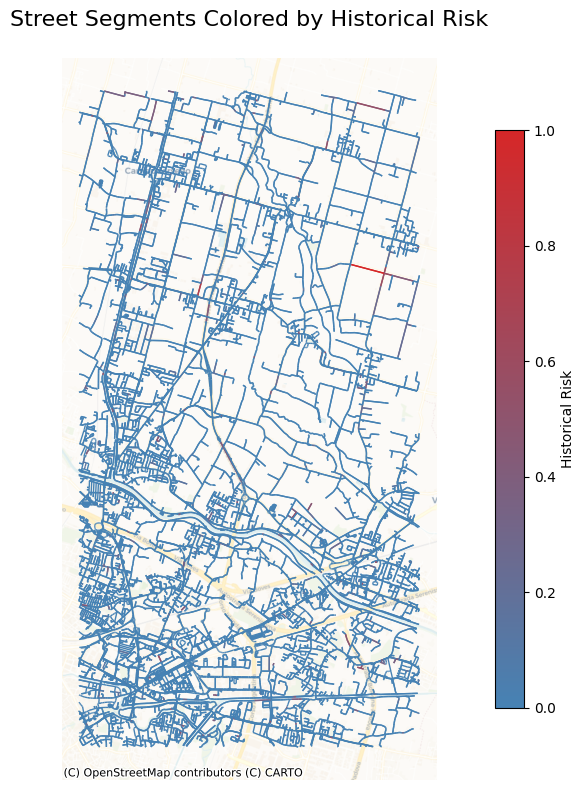

In [ ]:
cmap = LinearSegmentedColormap.from_list("blue_to_red", ["#4682B4", "#d62728"])

fig, ax = plt.subplots(figsize=(12, 8))
edges.plot(
    ax=ax,
    column='historical_penalty',
    cmap=cmap,
    linewidth=1,
    legend=True,
    legend_kwds={'label': "Historical Risk", 'shrink':0.8}
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.6
)

ax.set_title("Street Segments Colored by Historical Risk", fontsize=16, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

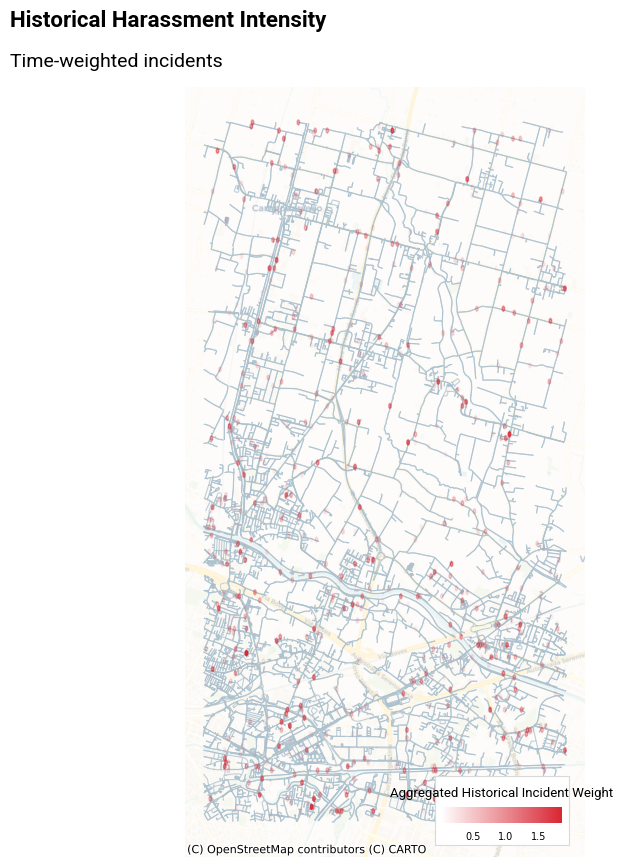

In [ ]:
edges_web = edges.to_crs(epsg=3857)
hist_web  = df_hist.to_crs(epsg=3857)

x = hist_web.geometry.x.values
y = hist_web.geometry.y.values
w = hist_web["weight"].values

cmap_alpha = LinearSegmentedColormap.from_list(
    "red_alpha", ["#D8263200", "#D82632FF"]
)

fig, ax = plt.subplots(figsize=(12, 10))

fig.text(x=0.2, y=0.94, s="Historical Harassment Intensity", size=16, font=bold)
fig.text(x=0.2, y=0.9, s="Time-weighted incidents", size=14, font=regular)

edges_web.plot(ax=ax, color="#ACC2CFFF", linewidth=0.8, alpha=0.8, zorder=2)

hb = ax.hexbin(
    x, y, C=w,
    reduce_C_function=np.sum,
    gridsize=150,
    cmap=cmap_alpha,
    mincnt=1,
    zorder=4
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, crs=edges_web.crs, alpha=0.4, zorder=0 )

box_ax = inset_axes(
    ax,
    width="35%", height="9%",
    loc="lower right",
    bbox_to_anchor=(0, 0.015, 0.96, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
box_ax.set_facecolor("white")
for s in box_ax.spines.values():
    s.set_visible(True); s.set_color("#d9d9d9"); s.set_linewidth(0.8)
box_ax.set_xticks([]); box_ax.set_yticks([])
box_ax.set_zorder(100)
box_ax.text(0.5, 0.65, "Aggregated Historical Incident Weight",
            ha="center", va="bottom", fontsize=9.5, font=regular)

cax = inset_axes(box_ax, width="90%", height="24%", loc="lower center", borderpad=1.6)
cb  = fig.colorbar(hb, cax=cax, orientation="horizontal")
cb.outline.set_visible(False)
cb.ax.tick_params(axis="x", which="both", labelsize=7, length=0, pad=6)
cb.ax.set_zorder(110)

ax.set_zorder(1)

ax.axis("off")
plt.savefig("historical_intesnity.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()

### 3. Safe spots as bonus

Just as we previously generated incidents randomly, we now create safe spots. These safe spots represent shops or local business prepared to assist someone who has just experienced Street Sexual Harassment.

In the same way that incidents create an area of insecurity around them, these safe spots generate an area of security in their surroundings.

In [ ]:
# Reproject
edges = edges.to_crs(epsg=3857)

# Get bounds of the current walkable network
minx, miny, maxx, maxy = edges.total_bounds  # (west, south, east, north)

# Shrink the box aprox 15% from each side to define a smaller "incident area"
margin_x = (maxx - minx) * 0.1
margin_y = (maxy - miny) * 0.1

safespots_box_geom = box(
    minx + margin_x,
    miny + margin_y,
    maxx - margin_x,
    maxy - margin_y
)

edges_for_safespots = edges[edges.within(safespots_box_geom)]

# We start randomly creating the incidents

sampled_safe = edges_for_safespots.sample(
    n=15,
    replace=True,
    weights=edges_for_safespots['length']
)

points_safe = sampled_safe.geometry.apply(
    lambda line: line.interpolate(random.random(), normalized=True)
)


safespots = gpd.GeoDataFrame(geometry=points_safe, crs=edges.crs)

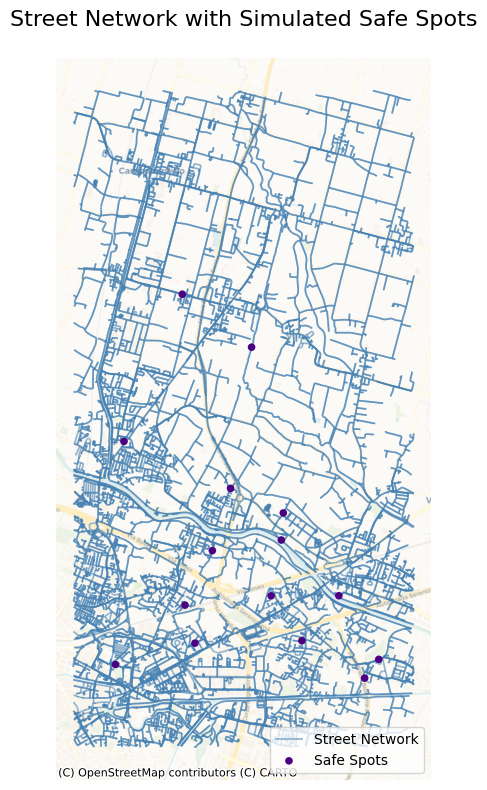

In [ ]:
edges = edges.to_crs(epsg=3857)
safespots = safespots.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot the street network
edges.plot(
    ax=ax,
    color='#4682B4',    # steelblue
    linewidth=1.2,
    alpha=0.6,
    label='Street Network'
)

# Overlay the incident points
safespots.plot(
    ax=ax,
    color='#4B0082',    # purple
    edgecolor='none',
    markersize=30,
    zorder=5,
    label='Safe Spots'
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.7
)

ax.set_title("Street Network with Simulated Safe Spots", fontsize=16, pad=12)
ax.axis('off')
ax.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
edges = edges.to_crs(epsg=3857)
safespots = safespots.to_crs(epsg=3857)

# Initialization bonus accumulator
edges['safe_bonus'] = 0.0

# For each spot, calculate distances and add linear bonus (limit = 100)
boost_limit = 100
for pt in safespots.geometry:
    d = edges.geometry.distance(pt)
    bonus = np.clip(1 - d / boost_limit, 0, 1)
    edges['safe_bonus'] += bonus

edges['safe_bonus'] = MinMaxScaler().fit_transform(
    edges[['safe_bonus']]
)

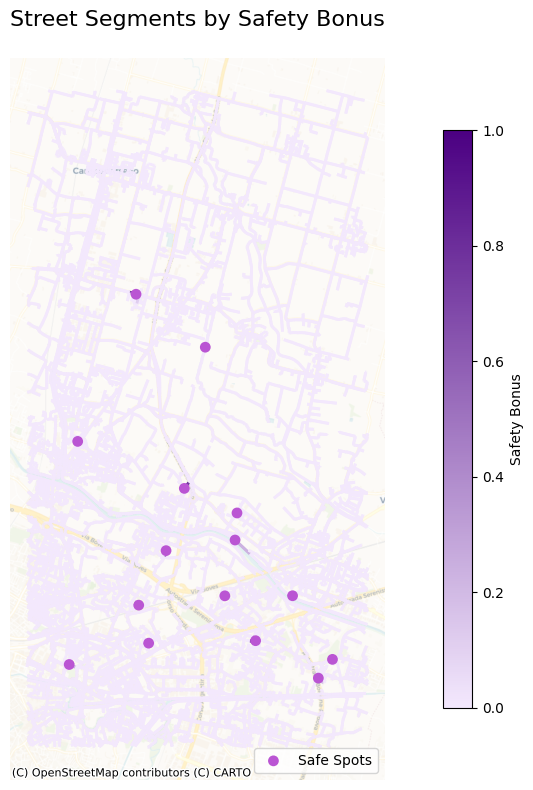

In [ ]:
edges = edges.to_crs(epsg=3857)
safespots = safespots.to_crs(epsg=3857)

# Custom colormap: very light violet to deep indigo
custom_purple = LinearSegmentedColormap.from_list(
    'light_to_indigo',
    ['#F3E8FD', '#4B0082']
)

# Network + Incident penalty
fig, ax = plt.subplots(figsize=(12, 8))
edges.plot(
    ax=ax,
    column='safe_bonus',
    cmap=custom_purple,
    linewidth=2,
    legend=True,
    legend_kwds={
        'label': "Safety Bonus",
        'shrink': 0.8
    }
)

# Safe Spots points
safespots.plot(
    ax=ax,
    color='#BA55D3',
    edgecolor='none',
    markersize=60,
    label='Safe Spots',
    zorder=5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs=edges.crs,
    alpha=0.6
)

ax.set_title("Street Segments by Safety Bonus", fontsize=16, pad=12)
ax.axis('off')
ax.legend(loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

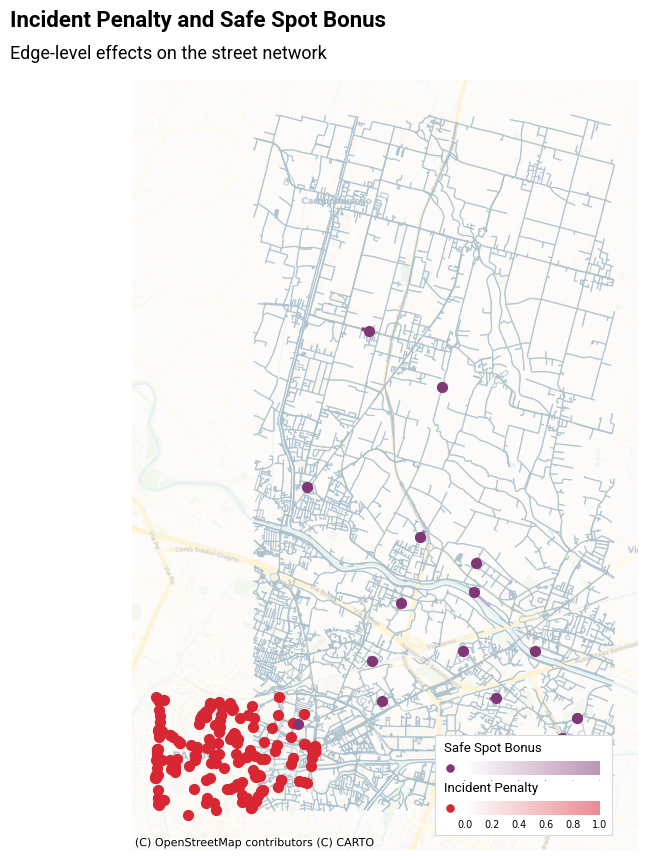

In [ ]:
edges_web = edges.to_crs(epsg=3857)
inc_web   = incidents.to_crs(epsg=3857)
safe_web  = safespots.to_crs(epsg=3857)

inc_cmap  = LinearSegmentedColormap.from_list("inc_alpha",  ["#D8263200", "#D8263288"])
safe_cmap = LinearSegmentedColormap.from_list("safe_alpha", ["#80377700", "#80377788"])


fig, ax = plt.subplots(figsize=(12, 10))

edges_web.plot(ax=ax, color="#ACC2CFFF", linewidth=0.8, alpha=0.8, zorder=2)

edges_web.loc[edges_web.incident_penalty > 0]\
    .plot(column='incident_penalty', cmap=inc_cmap,
          linewidth=2.5, ax=ax, zorder=2, legend=False)

edges_web.loc[edges_web.safe_bonus > 0]\
    .plot(column='safe_bonus', cmap=safe_cmap,
          linewidth=2.5, ax=ax, zorder=3, legend=False)

inc_web.plot(ax=ax, color='#D82632',
             markersize=50, label='Incidents', zorder=4)

safe_web.plot(ax=ax, color='#803777',
              markersize=50, label='Safe Spots', zorder=5)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, crs=edges_web.crs, alpha=0.45, zorder=0)

box_ax = inset_axes(
    ax,
    width="37%", height="13%",
    loc="lower right",
    bbox_to_anchor=(0, 0.02, 0.95, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

box_ax.set_facecolor("white")
for s in box_ax.spines.values():
    s.set_visible(True); s.set_color("#d9d9d9"); s.set_linewidth(0.8)
box_ax.set_xticks([]); box_ax.set_yticks([])
box_ax.set_zorder(100)

cax_safe = box_ax.inset_axes([0.17, 0.60, 0.76, 0.14])  # [x, y, w, h] in box coords
sm_safe  = ScalarMappable(cmap=safe_cmap); sm_safe.set_array([]); sm_safe.set_clim(0, 1)
cb_safe  = fig.colorbar(sm_safe, cax=cax_safe, orientation="horizontal")
cb_safe.outline.set_visible(False)
cb_safe.ax.set_xticks(np.linspace(0, 1, 6))
cb_safe.ax.tick_params(labelsize=0, length=0, pad=4)
box_ax.text(0.05, 0.8, "Safe Spot Bonus", ha="left", va="bottom", fontsize=9.5, transform=box_ax.transAxes, zorder=110, font=regular)

cax_inc = box_ax.inset_axes([0.17, 0.20, 0.76, 0.14])
sm_inc  = ScalarMappable(cmap=inc_cmap); sm_inc.set_array([]); sm_inc.set_clim(0, 1)
cb_inc  = fig.colorbar(sm_inc, cax=cax_inc, orientation="horizontal")
cb_inc.outline.set_visible(False)
cb_inc.ax.set_xticks(np.linspace(0, 1, 6))
cb_inc.ax.tick_params(labelsize=7, length=0, pad=4)
box_ax.text(0.05, 0.4, "Incident Penalty", ha="left", va="bottom", fontsize=9.5, transform=box_ax.transAxes, zorder=110, font=regular)

box_ax.scatter([0.085], [0.67], s=30, facecolor="#803777", edgecolor="#803777", linewidth=0.6,
               transform=box_ax.transAxes, zorder=110)

box_ax.scatter([0.085], [0.27], s=30, facecolor="#D82632", edgecolor="#D82632", linewidth=0.6,
               transform=box_ax.transAxes, zorder=110)

fig.text(0.20, 0.95, "Incident Penalty and Safe Spot Bonus",
        font=bold, size=16, ha="left", va="top")

fig.text(0.20, 0.915, "Edge-level effects on the street network",
        font=regular, size=13, ha="left", va="top")

ax.axis("off")
plt.savefig("incidents_safespots.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()

## Combining all parameters into a Safety Cost

We've independently calculated the safety-related weight of four components: edge length, recent incidents, historical incident density and safe spot proximity. Now, we are going to combine them into a single safety cost for each street segment. This cost will later be used as the weight in the routing algorithm to compute the safest path.

We will assign to each of the four parameters a weight based on its importance in the perception of safety:

* Length penalty: longer streets are considered riskier due to reduced opportunities to escape. Nevertheless, this factor is given moderate importance.
* Active incident penalty: these are the most immediate indicators of danger. Segments near recent reports will be the most penalized.
* Historical risk: locations with recurrent incidents suggest structural or environmental risk, they'll recieve significant weight.
* Safe spot bonus: proximity to trusted locations reduces the perceived risk. This factor acts as a bonus which is substracted from the total cost.

We calculate the `combined_cost`for each edge using a weighted sum:

In [ ]:
edges["combined_cost"] = (
    0.4 * edges["intersections_penalty"] +
    1.2 * edges["incident_penalty"] +
    0.8 * edges["historical_penalty"] -
    0.6 * edges["safe_bonus"]
).clip(lower=0.0)

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
edges["combined_cost"] = scaler.fit_transform(edges[["combined_cost"]]).ravel()

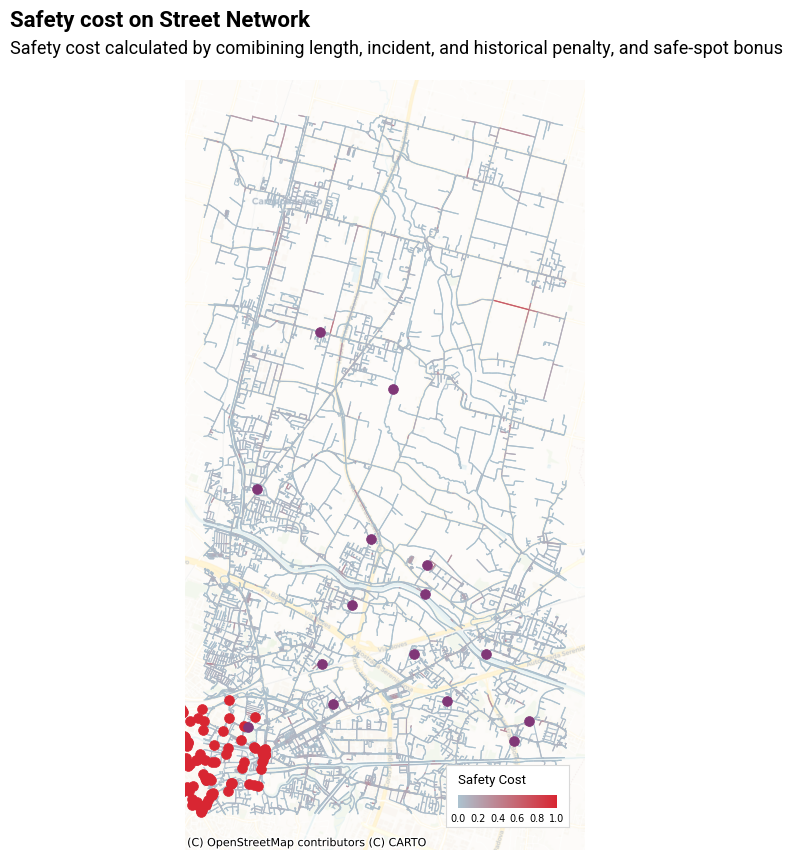

In [ ]:
edges_web = edges.to_crs(epsg=3857)
inc_web   = incidents.to_crs(epsg=3857)
safe_web  = safespots.to_crs(epsg=3857)

cost_cmap = LinearSegmentedColormap.from_list("grey_to_red", ["#ACC2CFFF", "#D82632"])

fig, ax = plt.subplots(figsize=(12, 10))

edges_web.plot(
    ax=ax,
    column="combined_cost",
    cmap=cost_cmap,
    vmin=0, vmax=1,
    linewidth=0.8,
    legend=False,
    zorder=2
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, crs=edges_web.crs, alpha=0.45, zorder=0)

inc_web.plot(ax=ax, color="#D82632", edgecolor="#D82632", linewidth=0.5, markersize=50, zorder=4)
safe_web.plot(ax=ax, color="#803777", edgecolor="#803777", linewidth=0.5, markersize=50, zorder=5)

box_ax = inset_axes(
    ax, width="32%", height="8%",
    loc="lower right",
    bbox_to_anchor=(0, 0.03, 0.96, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
box_ax.set_facecolor("white")
for s in box_ax.spines.values():
    s.set_visible(True); s.set_color("#d9d9d9"); s.set_linewidth(0.8)
box_ax.set_xticks([]); box_ax.set_yticks([]); box_ax.set_zorder(100)

cax = box_ax.inset_axes([0.1, 0.3, 0.8, 0.22])

sm = ScalarMappable(cmap=cost_cmap); sm.set_array([]); sm.set_clim(0, 1)
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.outline.set_visible(False)
cb.ax.set_xticks(np.linspace(0, 1, 6))
cb.ax.tick_params(labelsize=7, length=0, pad=4)
box_ax.text(0.10, 0.65, "Safety Cost", ha="left", va="bottom", fontsize=9.5, transform=box_ax.transAxes, zorder=110, font=regular)

fig.text(
    0.20, 0.95,
    "Safety cost on Street Network",
    font=bold, size=16, ha="left", va="top"
)

fig.text(
    0.20, 0.92,
    "Safety cost calculated by comibining length, incident, and historical penalty, and safe-spot bonus",
    font=regular, size=13, ha="left", va="top"
)

ax.axis("off")

plt.savefig("safety_cost.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()

## Routing

Now that we've computed the `combined_cost`for each segment, we can use the score to generate safe walking routes.

Before computing routes, we need to assign the penalties, bonus and combined cost to the G graph. We dod this by looping over all the edges in the graph and assigning the corresponding values to the dataframe.

In [ ]:
for u, v, k, data in G.edges(keys=True, data=True):
    if (u, v, k) in edges.index:
        attrs = edges.loc[(u, v, k)]
        data.update({
            'intersections_penalty'    : attrs.intersections_penalty,
            'incident_penalty'         : attrs.incident_penalty,
            'historical_penalty'       : attrs.historical_penalty,
            'safe_bonus'               : attrs.safe_bonus,
            'combined_cost'            : attrs.combined_cost
        })

Once we have the coordinates of the origin and destination, we find the closet graph nodes and calculate two routes:

* The shortest route, which minimizes geographic distance and time.
* The safest route, which minimizes our custom `combined_cost` that integrates penalties and bonuses.

In [ ]:
# snap to nearest nodes
orig_lat, orig_lon = origin_coords
dst_lat,  dst_lon  = destination_coords

orig_node = ox.distance.nearest_nodes(G, X=orig_lon, Y=orig_lat)
dest_node = ox.distance.nearest_nodes(G, X=dst_lon, Y=dst_lat)

# compute the two routes directly
shortest = nx.shortest_path(G, orig_node, dest_node, weight='length')
safest   = nx.shortest_path(G, orig_node, dest_node, weight='combined_cost')

# build GeoDataFrame
# For each node in n, it gets latitude and latitude and use LineString to create a route as a line
def to_line(route):
    return LineString([(G.nodes[n]['x'], G.nodes[n]['y']) for n in route])

records = [
    {'route':'Shortest', 'geometry': to_line(shortest)},
    {'route':'Safest',   'geometry': to_line(safest)},
]

routes = (gpd.GeoDataFrame(records, crs="EPSG:4326")
            .to_crs(epsg=3857))

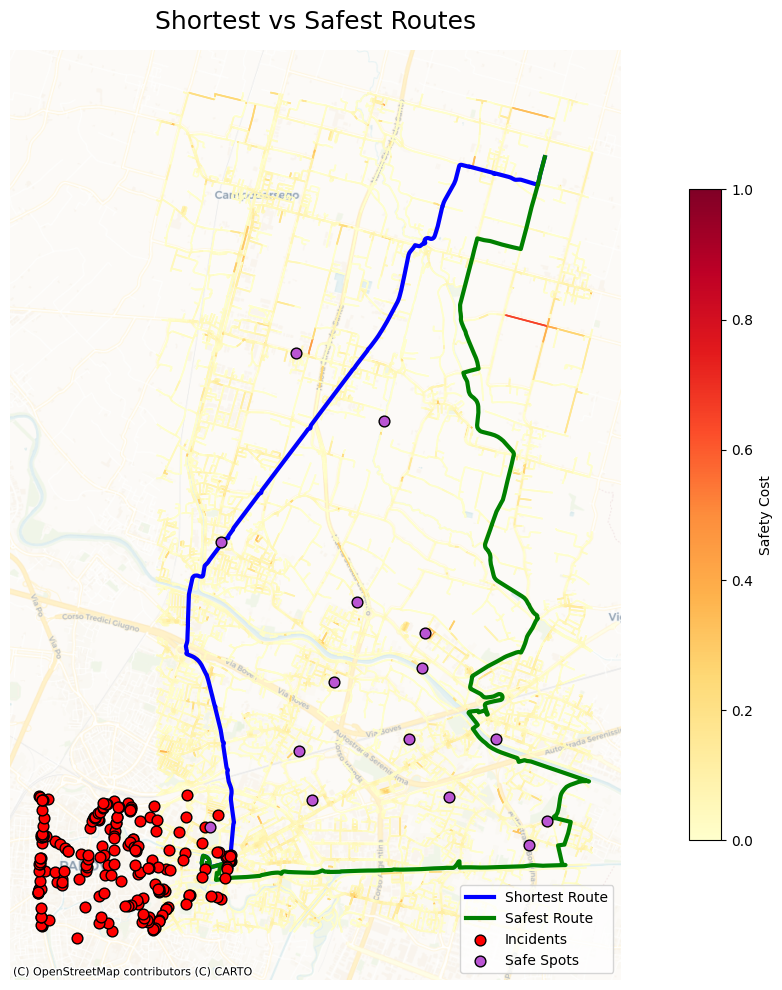

In [ ]:
edges_web   = edges.to_crs(epsg=3857)
routes_web  = routes.to_crs(epsg=3857)
inc_web     = incidents.to_crs(epsg=3857)
safe_web    = safespots.to_crs(epsg=3857)

colors = {
    "Shortest": "blue",
    "Safest"  : "green"
}

fig, ax = plt.subplots(figsize=(14, 10))

edges_web.plot(
    ax=ax, column="combined_cost", cmap="YlOrRd",
    linewidth=1.2, legend=True,
    legend_kwds={"label":"Safety Cost","shrink":0.7},
    zorder=1
)

for _, row in routes_web.iterrows():
    if row.route in colors:
        ax.plot(
            *row.geometry.xy,
            color=colors[row.route],
            linewidth=3,
            label=f"{row.route} Route",
            zorder=3
        )

inc_web.plot(ax=ax, color="red",  edgecolor="black", markersize=60, label="Incidents", zorder=4)
safe_web.plot(ax=ax,color="#BA55D3", edgecolor="black", markersize=60, label="Safe Spots",  zorder=5)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager,
                crs=edges_web.crs, alpha=0.6)
ax.set_title("Shortest vs Safest Routes", fontsize=18, pad=15)
ax.axis("off")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

So far, we have compared the shortest and the safest routes. However, users may be interested in a middle solution: a route that is slightly longer than the shortest, but significantly safer than the riskiest option. For this reason, we propose a third alternative, called the balanced route, which combines both safety and distance criteria using a weighted formula.

This combined cost is defined as:

$$
\text{weight_cost} = \alpha \times \text{normalized_length} + \beta \times \text{normalized_combined_cost}
$$

Where:
*   𝛼 is the weight given to distance,
*   𝛽 is the weight given to safety,
*   `normalized_length` is the street segment length scaled between 0 and 1,
*   `normalized_combined_cost`is the safety penalty also scaled between 0 and 1.

First, we normalize both parameters and define the new weighted cost. And then we apply the weight_cost to the graph G.

In [ ]:
edges = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

#Normalization
scaler = MinMaxScaler()

edges[['len_s','cost_s']] = scaler.fit_transform(
    edges[['length','combined_cost']]
)

alpha = 0.3  # weight for distance
beta = 0.7   # weight for safety

# Calculation of weight cost
edges['weight_cost'] = alpha*edges['len_s'] + beta*edges['cost_s']

edges.set_index(['u','v','key'], inplace=True)

nx.set_edge_attributes(
    G,
    values=edges['weight_cost'].to_dict(),
    name='weight_cost'
)

Using this new column, we calculate the balanced route and then we visualize the three routes.

In [ ]:
# Nearest nodes to coordinates
orig_node = ox.nearest_nodes(G, X=origin_coords[1], Y=origin_coords[0])
dest_node = ox.nearest_nodes(G, X=destination_coords[1], Y=destination_coords[0])

# Compute routes
shortest_route = nx.shortest_path(G, source=orig_node, target=dest_node, weight='length')
safest_route   = nx.shortest_path(G, source=orig_node, target=dest_node, weight='combined_cost')
balanced_route = nx.shortest_path(G, source=orig_node, target=dest_node, weight='weight_cost')

# Create routes as lines
def route_to_linestring(route):
    return LineString([(G.nodes[n]['x'], G.nodes[n]['y']) for n in route])

records = [
    {'route':'Shortest', 'geometry': route_to_linestring(shortest_route)},
    {'route':'Safest',   'geometry': route_to_linestring(safest_route)},
    {'route':'Balanced', 'geometry': route_to_linestring(balanced_route)},
]

routes = (
    gpd.GeoDataFrame(records, crs="EPSG:4326")
       .to_crs(epsg=3857)
)

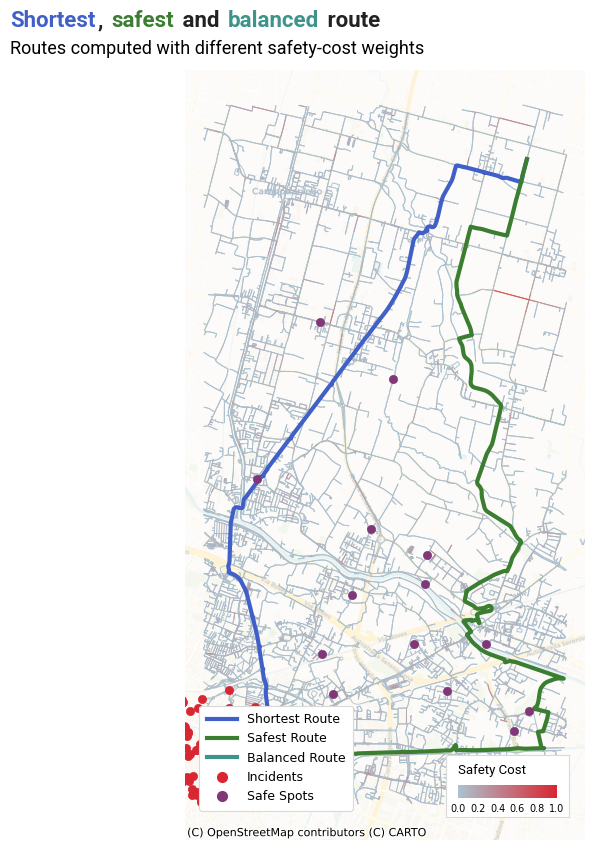

In [ ]:
edges_web = edges.to_crs(epsg=3857)
inc_web   = incidents.to_crs(epsg=3857)
safe_web  = safespots.to_crs(epsg=3857)

cost_cmap = LinearSegmentedColormap.from_list("grey_to_red", ["#ACC2CFFF", "#D82632"])

fig, ax = plt.subplots(figsize=(12, 10))

edges_web.plot(
    ax=ax,
    column="combined_cost",
    cmap=cost_cmap,
    vmin=0, vmax=1,
    linewidth=0.7,
    legend=False,
    zorder=2
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, crs=edges_web.crs, alpha=0.45, zorder=0)

inc_web.plot(ax=ax, color="#D82632", edgecolor="#D82632", linewidth=0.5, markersize=35, zorder=4)
safe_web.plot(ax=ax, color="#803777", edgecolor="#803777", linewidth=0.5, markersize=35, zorder=5)

box_ax = inset_axes(
    ax, width="32%", height="8%",
    loc="lower right",
    bbox_to_anchor=(0, 0.03, 0.96, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
box_ax.set_facecolor("white")
for s in box_ax.spines.values():
    s.set_visible(True); s.set_color("#d9d9d9"); s.set_linewidth(0.8)
box_ax.set_xticks([]); box_ax.set_yticks([]); box_ax.set_zorder(100)

cax = box_ax.inset_axes([0.1, 0.3, 0.8, 0.22])

sm = ScalarMappable(cmap=cost_cmap); sm.set_array([]); sm.set_clim(0, 1)
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.outline.set_visible(False)
cb.ax.set_xticks(np.linspace(0, 1, 6))
cb.ax.tick_params(labelsize=7, length=0, pad=4)
box_ax.text(0.10, 0.65, "Safety Cost", ha="left", va="bottom", fontsize=9.5, transform=box_ax.transAxes, zorder=110, font=regular)

colors = {
    "Shortest": "#4060C8FF",
    "Safest"  : "#3B7D31FF",
    "Balanced": "#3E938BFF"
}

for _, row in routes_web.iterrows():
    ax.plot(
        *row.geometry.xy,
        color=colors[row.route],
        linewidth=3,
        label=f"{row.route} Route",
        zorder=3
    )

title_box = HPacker(
    children=[
        TextArea("Shortest", textprops=dict(font=bold, size=16, color=colors["Shortest"])),
        TextArea(", ",       textprops=dict(font=bold, size=16, color="#222")),
        TextArea("safest",   textprops=dict(font=bold, size=16, color=colors["Safest"])),
        TextArea(" and ",    textprops=dict(font=bold, size=16, color="#222")),
        TextArea("balanced", textprops=dict(font=bold, size=16, color=colors["Balanced"])),
        TextArea(" route",   textprops=dict(font=bold, size=16, color="#222")),
    ],
    align="baseline", pad=0, sep=2
)

anch = AnchoredOffsetbox(
    loc="upper left",
    child=title_box,
    pad=0, frameon=False,
    bbox_to_anchor=(0.20, 0.94),
    bbox_transform=fig.transFigure,
    borderpad=0
)
ax.add_artist(anch)

fig.text(
    0.20, 0.91,
    "Routes computed with different safety-cost weights",
    font=regular, size=13, ha="left", va="top"
)

handles = [
    Line2D([0], [0], color=colors["Shortest"], lw=3, label="Shortest Route"),
    Line2D([0], [0], color=colors["Safest"],   lw=3, label="Safest Route"),
    Line2D([0], [0], color=colors["Balanced"], lw=3, label="Balanced Route"),
    Line2D([0], [0], marker='o', linestyle='none',
           markerfacecolor="#D82632", markeredgecolor="#D82632",
           markersize=7, label="Incidents"),
    Line2D([0], [0], marker='o', linestyle='none',
           markerfacecolor="#803777", markeredgecolor="#803777",
           markersize=7, label="Safe Spots"),
]

leg = ax.legend(
    handles=handles,
    loc="lower left", bbox_to_anchor=(0.02, 0.03),
    frameon=True, fontsize=9, ncol=1,
    handlelength=2.4, handletextpad=0.8, borderpad=0.6
)

frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#d9d9d9")
frame.set_linewidth(0.8)
frame.set_alpha(1.0)

ax.axis("off")

plt.savefig("shortest_safest_balanced.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()

In [ ]:
edges_df = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

# Functopm to tale route statistics
def get_route_metrics(route, G, edges_df, walking_speed_kmh=4.8):
    """
    Returns a dict with:
      - Total Distance (m)
      - Estimated Time (Xm Ys)
      - Total Safety Cost
      - Avg. Incident Penalty
    """
    # convert walking speed to m/s
    mps = walking_speed_kmh * 1000 / 3600.0
    total_len = total_cost = total_inc = 0.0

    #"walks" each segment of the route

    for u, v in zip(route[:-1], route[1:]):

        mask_uv = ((edges_df.u==u)&(edges_df.v==v))|((edges_df.u==v)&(edges_df.v==u)) #endpoits match
        row = edges_df[mask_uv].iloc[0]

        total_len  += row["length"] #sums length
        total_cost += row.get("combined_cost", 0) #sums cost
        total_inc  += row.get("incident_penalty", 0) #sums incident penalty

    # travel time
    secs = total_len / mps
    mins, sec = divmod(int(secs), 60)
    time_str = f"{mins}m {sec}s"

    # average incident penalty per segment
    avg_inc = total_inc / (len(route) - 1)

    # returns summary
    return {
        "Total Distance (m)"  : round(total_len, 1),
        "Estimated Time"      : time_str,
        "Total Safety Cost"   : round(total_cost, 3),
        "Avg Incident Penalty": round(avg_inc,   3),
    }

# Gets metrics for the three routes
shortest_stats = get_route_metrics(shortest_route, G, edges_df)
safest_stats   = get_route_metrics(safest_route,   G, edges_df)
balanced_stats = get_route_metrics(balanced_route, G, edges_df)

routes_df = pd.DataFrame(
    [shortest_stats, safest_stats, balanced_stats],
    index=["Shortest","Safest","Balanced"]
)
routes_df.index.name = "Route"
display(routes_df)

,Total Distance (m),Estimated Time,Total Safety Cost,Avg Incident Penalty
Route,,,,
Shortest,15573.0,194m 39s,54.627,0.032
Safest,23735.6,296m 41s,19.057,0.004
Balanced,20397.0,254m 57s,19.896,0.004


In [ ]:
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()
edges_gdf.set_index(["u", "v", "key"], inplace=True)

# Normalize
scaler = MinMaxScaler()
edges_gdf[["len_s", "cost_s"]] = scaler.fit_transform(
    edges_gdf[["length", "combined_cost"]]
)

# Weights
weights = [0.1, 0.4, 0.6, 0.9]
routes = []

# For each weight we
for beta in weights:
  # Assign the cost to each edge
    alpha = 1 - beta
    edges_gdf["weight_cost"] = alpha * edges_gdf["len_s"] + beta * edges_gdf["cost_s"]
  # Attach the cost to the edge as an attribute
    nx.set_edge_attributes(
        G,
        values=edges_gdf["weight_cost"].to_dict(),
        name="weight_cost",
    )
  # Find the best route using the cost
    route_nodes = nx.shortest_path(G, source=orig_node, target=dest_node, weight="weight_cost")
  # Turn the path into a line
    coords = [(G.nodes[n]["x"], G.nodes[n]["y"]) for n in route_nodes]
    geom = LineString(coords)

    routes.append(gpd.GeoSeries([geom], crs="EPSG:4326").to_crs(epsg=3857))

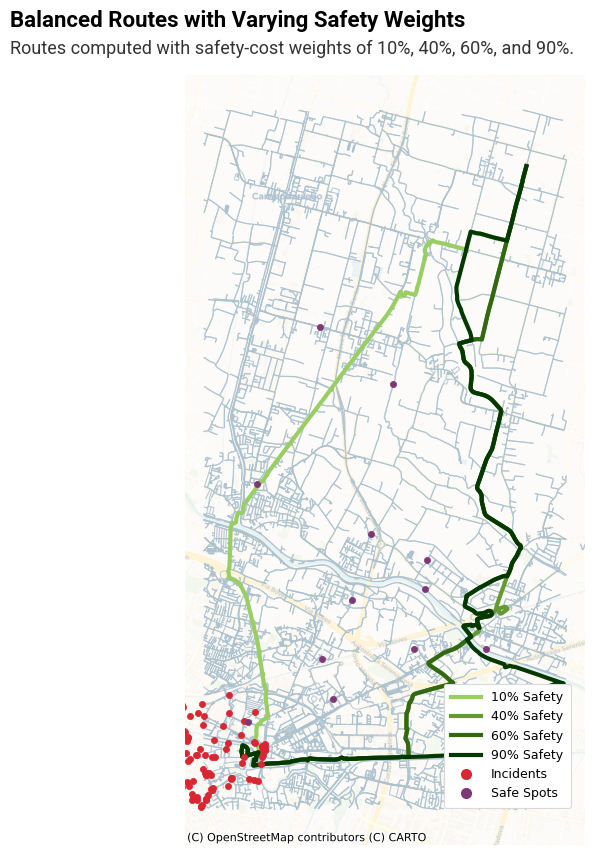

In [ ]:
edges_web = edges.to_crs(epsg=3857)
inc_web   = incidents.to_crs(epsg=3857)
safe_web  = safespots.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

edges_web.plot(ax=ax, color="#ACC2CFFF", linewidth=0.8, alpha=0.85, zorder=2)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager,
                crs=edges_web.crs, alpha=0.45, zorder=0)

inc_web.plot(ax=ax,  color="#D82632", edgecolor="#D82632",
             linewidth=0.5, markersize=20, zorder=4)

safe_web.plot(ax=ax, color="#803777", edgecolor="#803777",
              linewidth=0.5, markersize=20, zorder=5)

colors = ['#99CE64FF', '#659A32FF', '#326812FF', '#033800FF']
labels = ['10% Safety', '40% Safety', '60% Safety', '90% Safety']

for gs, color, label in zip(routes, colors, labels):
    gs.plot(ax=ax, color=color, linewidth=3.0, zorder=3, label=label)

handles = [
    # 4 balanced routes
    Line2D([0], [0], color=colors[0], lw=3, label=labels[0]),
    Line2D([0], [0], color=colors[1], lw=3, label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=3, label=labels[2]),
    Line2D([0], [0], color=colors[3], lw=3, label=labels[3]),
    # points
    Line2D([0], [0], marker='o', linestyle='none',
           markerfacecolor="#D82632", markeredgecolor="#D82632",
           markersize=7, label="Incidents"),
    Line2D([0], [0], marker='o', linestyle='none',
           markerfacecolor="#803777", markeredgecolor="#803777",
           markersize=7, label="Safe Spots"),
]

leg = ax.legend(
    handles=handles,
    loc="lower right", bbox_to_anchor=(0.98, 0.04),  # nudge position here
    frameon=True, fontsize=9, ncol=1,
    handlelength=2.4, handletextpad=0.8, borderpad=0.6
)

# Style the legend box to match the thesis aesthetic
frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#d9d9d9")
frame.set_linewidth(0.8)
frame.set_alpha(1.0)

fig.text(
    0.20, 0.945,
    "Balanced Routes with Varying Safety Weights",
    font=bold, size=16, ha="left", va="top"
)

fig.text(
    0.20, 0.915,
    "Routes computed with safety-cost weights of 10%, 40%, 60%, and 90%.",
    font=regular, size=13, ha="left", va="top", color="#333333"
)

ax.axis("off")
plt.savefig("balanced_routes.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()

In [ ]:
edges_df = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

# Getting statistics for the routes (same as before)
def get_route_metrics(route, G, edges_df, walking_speed_kmh=4.8):
    mps = walking_speed_kmh * 1000 / 3600
    total_len = total_cost = total_inc = 0.0

    for u, v in zip(route[:-1], route[1:]):
        mask = ((edges_df.u == u) & (edges_df.v == v)) | ((edges_df.u == v) & (edges_df.v == u))
        row = edges_df[mask].iloc[0]
        total_len  += row["length"] # sum length
        total_cost += row.get("combined_cost", 0) #sum combined cost
        total_inc  += row.get("incident_penalty", 0) #sum incident penalty

    secs    = total_len / mps
    mins, s = divmod(int(secs), 60)
    time_str = f"{mins}m {s}s"
    avg_inc  = total_inc / (len(route) - 1)

    return {
        "Total Distance (m)"    : round(total_len, 1),
        "Estimated Time"        : time_str,
        "Total Safety Cost"     : round(total_cost, 3),
        "Avg. Incident Penalty" : round(avg_inc, 3),
    }

# Normalization
scaler = MinMaxScaler()
edges_df[['len_s','cost_s']] = scaler.fit_transform(edges_df[['length','combined_cost']])
edges_df.set_index(['u','v','key'], inplace=True)

# Assigning to each edge the weight cost
def set_weight_cost(alpha, beta):
    edges_df['weight_cost'] = alpha * edges_df['len_s'] + beta * edges_df['cost_s']
    nx.set_edge_attributes(G, values=edges_df['weight_cost'].to_dict(), name='weight_cost')

# Calculating routes
orig = ox.nearest_nodes(G, X=origin_coords[1], Y=origin_coords[0])
dest = ox.nearest_nodes(G, X=destination_coords[1], Y=destination_coords[0])

# Route dictionary: name, attribute, weight
route_dict = {
    "Shortest"   : ('length',       None),
    "Safest"     : ('combined_cost',None),
    "10% Safety" : ('weight_cost',  (0.9, 0.1)),
    "40% Safety" : ('weight_cost',  (0.6, 0.4)),
    "60% Safety" : ('weight_cost',  (0.4, 0.6)),
    "90% Safety" : ('weight_cost',  (0.1, 0.9)),
}

records = []

# Loop through all route types, calculates the route, gets route stats and saves them in records
for name, (weight_attr, blend) in route_dict.items():
    if blend is not None:
        alpha, beta = blend
        set_weight_cost(alpha, beta)

    path = nx.shortest_path(G, source=orig, target=dest, weight=weight_attr)
    stats = get_route_metrics(path, G, edges_df.reset_index())
    stats["Route"] = name
    records.append(stats)

routes_df = (
    pd.DataFrame(records)
      .set_index("Route")
      .loc[["Shortest","10% Safety","40% Safety","60% Safety","90% Safety","Safest"]]
)
display(routes_df)

,Total Distance (m),Estimated Time,Total Safety Cost,Avg. Incident Penalty
Route,,,,
Shortest,15573.0,194m 39s,54.627,0.032
10% Safety,15921.1,199m 0s,29.831,0.006
40% Safety,18984.8,237m 18s,20.753,0.005
60% Safety,19700.2,246m 15s,20.247,0.004
90% Safety,23735.6,296m 41s,19.057,0.004
Safest,23735.6,296m 41s,19.057,0.004


In [ ]:
edges_wgs = edges.to_crs(epsg=4326)

# Reduced bounding box
minx, miny, maxx, maxy = edges_wgs.total_bounds
pad_x = (maxx - minx) * 0.1
pad_y = (maxy - miny) * 0.1
sampling_bbox = box(minx+pad_x, miny+pad_y, maxx-pad_x, maxy-pad_y)

candidates = edges_wgs[edges_wgs.intersects(sampling_bbox)]

# Generating 100 pairs
pairs = []

while len(pairs) < 100:

    o_seg = candidates.sample(1).iloc[0].geometry
    d_seg = candidates.sample(1).iloc[0].geometry
  #Random point on segment
    o_pt  = o_seg.interpolate(random.random(), normalized=True)
    d_pt  = d_seg.interpolate(random.random(), normalized=True)
  #Snaps points to graph
    o_node = ox.nearest_nodes(G, X=o_pt.x, Y=o_pt.y)
    d_node = ox.nearest_nodes(G, X=d_pt.x, Y=d_pt.y)
    try:
      #checks a path exists ad calculates the shortest path length
        dist = nx.shortest_path_length(G, source=o_node, target=d_node, weight="length")
    except nx.NetworkXNoPath:
        continue

    # accept only if distance ≥ 500 m
    if dist >= 500:
        pairs.append({
            "orig_lat"    : o_pt.y,
            "orig_lon"    : o_pt.x,
            "dest_lat"    : d_pt.y,
            "dest_lon"    : d_pt.x,
            "route_length": dist
        })

pairs_df = pd.DataFrame(pairs)
print(pairs_df)

     orig_lat   orig_lon   dest_lat   dest_lon  route_length
0   45.470247  11.917404  45.429548  11.965132   7232.977808
1   45.485286  11.904364  45.447421  11.946641   6964.654247
2   45.414281  11.923253  45.420681  11.958038   4634.982490
3   45.455568  11.902476  45.457723  11.911622   1282.546465
4   45.472642  11.931704  45.435047  11.906534   6954.664119
..        ...        ...        ...        ...           ...
95  45.410997  11.943011  45.494618  11.942034  11523.215334
96  45.470531  11.900493  45.440211  11.900197   4757.317895
97  45.477706  11.926007  45.495310  11.933932   2943.750709
98  45.492147  11.929153  45.444964  11.927483   6779.703215
99  45.504983  11.925636  45.467098  11.903725   5267.242114

[100 rows x 5 columns]


In [ ]:
avg_lat = pairs_df[['orig_lat','dest_lat']].values.mean()
avg_lon = pairs_df[['orig_lon','dest_lon']].values.mean()
m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

# Draw each pair with its own random color
for idx, row in pairs_df.iterrows():
    color = "#{:06x}".format(random.randint(0, 0xFFFFFF))
    folium.PolyLine(
        locations=[(row.orig_lat, row.orig_lon),
                   (row.dest_lat, row.dest_lon)],
        color=color,
        weight=4, opacity=0.8,
        tooltip=f"Pair {idx}"
    ).add_to(m)
    folium.CircleMarker(
        location=(row.orig_lat, row.orig_lon),
        radius=3, color=color, fill=True, fill_opacity=0.8
    ).add_to(m)
    folium.CircleMarker(
        location=(row.dest_lat, row.dest_lon),
        radius=3, color=color, fill=True, fill_opacity=0.8
    ).add_to(m)

m

In [ ]:
# Getting the nearest node
node_list = [(n, data['x'], data['y']) for n, data in G.nodes(data=True)]
def get_nearest_node(x, y):
    return min(node_list, key=lambda t: (t[1]-x)**2 + (t[2]-y)**2)[0]

edges_df = edges.reset_index()

# Normalization
scaler = MinMaxScaler()
edges_df[['len_s','cost_s']] = scaler.fit_transform(
    edges_df[['length','combined_cost']]
)

# 40% and 60% safety weights
edges_df['weight_40'] = 0.6*edges_df['len_s'] + 0.4*edges_df['cost_s']
edges_df['weight_60'] = 0.4*edges_df['len_s'] + 0.6*edges_df['cost_s']

# Push weights into the graph
edges_df.set_index(['u','v','key'], inplace=True)
nx.set_edge_attributes(G, edges_df['weight_40'].to_dict(), name='weight_40')
nx.set_edge_attributes(G, edges_df['weight_60'].to_dict(), name='weight_60')

# Definition of weights
route_specs = {
    'Shortest'   : 'length',
    '40% Safety' : 'weight_40',
    '60% Safety' : 'weight_60',
    'Safest'     : 'combined_cost'
}

# For each route, we compute the four routes (snap to nearst node, shortest path with weight, turn path into line)
routes = []
for idx, row in pairs_df.iterrows():
    orig = get_nearest_node(row.orig_lon, row.orig_lat)
    dest = get_nearest_node(row.dest_lon, row.dest_lat)
    for label, weight in route_specs.items():
        path = nx.shortest_path(G, source=orig, target=dest, weight=weight)
        geom = LineString([(G.nodes[n]['x'], G.nodes[n]['y']) for n in path])
        routes.append({
            'pair_id': idx,
            'route_type': label,
            'geometry': geom
        })

routes_gdf = (
    gpd.GeoDataFrame(routes, crs="EPSG:4326")
       .to_crs(epsg=3857)
)

routes_gdf.head()

,pair_id,route_type,geometry
0,0,Shortest,"LINESTRING (1326635.015 5695860.198, 1326675.6..."
1,0,40% Safety,"LINESTRING (1326635.015 5695860.198, 1326675.6..."
2,0,60% Safety,"LINESTRING (1326635.015 5695860.198, 1326675.6..."
3,0,Safest,"LINESTRING (1326635.015 5695860.198, 1326675.6..."
4,1,Shortest,"LINESTRING (1325188.507 5698246.503, 1325196.6..."


In [ ]:
edges_df = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

metrics = []
walk_speed_mps = 5000/3600  # walking at 5 km/h

# For every pair and every route type we get closer node and compute the path with weight
for idx, row in pairs_df.iterrows():
    o_node = get_nearest_node(row.orig_lon, row.orig_lat)
    d_node = get_nearest_node(row.dest_lon, row.dest_lat)

    for label, weight in route_specs.items():
        path = nx.shortest_path(G, source=o_node, target=d_node, weight=weight)

    # Accumulate path statistics
        total_len = total_cost = total_inc = 0.0
        for u, v in zip(path[:-1], path[1:]):
            data = G.edges[u, v, 0] if G.is_multigraph() else G.edges[u, v]
            total_len  += data["length"]                      # sum length
            total_cost += data["combined_cost"]               # sum combined cost
            total_inc  += data.get("incident_penalty", 0.0)   # sum incident penalty

        # compute time and average penalty
        t_sec = total_len / walk_speed_mps
        m, s = divmod(int(t_sec), 60)
        time_str = f"{m}m {s}s"
        avg_pen  = total_inc / total_len if total_len else 0.0

      # Store one row per each pair and route type
        metrics.append({
            "route_type"            : label,
            "Total Distance (m)"    : total_len,
            "Estimated Time"        : time_str,
            "Total Safety Cost"     : total_cost,
            "Avg. Incident Penalty" : avg_pen
        })

metrics_df = pd.DataFrame(metrics)

# Parse to use minutes and seconds for the estimated time
m_s = metrics_df["Estimated Time"].str.extract(r"(\d+)m (\d+)s").astype(int)
metrics_df["est_time_s"] = m_s[0]*60 + m_s[1]

# Aggregate for all pairs, by route type
summary = (
    metrics_df
      .groupby("route_type")
      .agg(
        mean_distance_m         = ("Total Distance (m)",    "mean"),
        median_distance_m       = ("Total Distance (m)",    "median"),
        mean_time_s             = ("est_time_s",             "mean"),
        median_time_s           = ("est_time_s",             "median"),
        mean_safety_cost        = ("Total Safety Cost",      "mean"),
        median_safety_cost      = ("Total Safety Cost",      "median"),
        mean_incident_penalty   = ("Avg. Incident Penalty",  "mean"),
        median_incident_penalty = ("Avg. Incident Penalty",  "median"),
      )
      .round(2)
      .reset_index()
)

# Order of rows
order = ["Shortest","40% Safety","60% Safety","Safest"]
summary = summary.set_index("route_type").loc[order].reset_index()

display(summary)

,route_type,mean_distance_m,median_distance_m,mean_time_s,median_time_s,mean_safety_cost,median_safety_cost,mean_incident_penalty,median_incident_penalty
0,Shortest,6252.62,5799.78,4501.45,4175.5,10.68,9.34,0.0,0.0
1,40% Safety,6756.12,6285.37,4863.91,4525.0,8.39,6.92,0.0,0.0
2,60% Safety,7285.25,6976.48,5244.92,5022.5,7.82,6.92,0.0,0.0
3,Safest,8457.56,7433.17,6088.98,5351.5,7.53,6.67,0.0,0.0


In [ ]:
edges_df = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

walk_speed_mps = 5000/3600  # 5 km/h in m/s

# Calculate statistics for every pair and route type
metrics = []
# Looping through each pair and snapping nearest node
for idx, row in pairs_df.iterrows():
    o_node = get_nearest_node(row.orig_lon, row.orig_lat)
    d_node = get_nearest_node(row.dest_lon, row.dest_lat)
  # For each routing strategy, it runs the shortest path with the edge weight
    for label, weight in route_specs.items():
        path = nx.shortest_path(G, source=o_node, target=d_node, weight=weight)
        # sum up edge‐attributes
        tot_len = tot_cost = tot_inc = 0.0
        for u, v in zip(path[:-1], path[1:]):
            data = G.edges[u, v, 0] if G.is_multigraph() else G.edges[u, v]
            tot_len  += data["length"]
            tot_cost += data["combined_cost"]
            tot_inc  += data.get("incident_penalty", 0.0)
        # converting distance into time
        sec = tot_len / walk_speed_mps
        m, s = divmod(int(sec), 60)
        time_str = f"{m}m {s}s"
        avg_pen  = tot_inc/tot_len if tot_len else 0.0
        # one row per pair and route type
        metrics.append({
            "pair_id"               : idx,
            "route_type"            : label,
            "Total Distance (m)"    : round(tot_len, 1),
            "Estimated Time"        : time_str,
            "Total Safety Cost"     : round(tot_cost, 3),
            "Avg. Incident Penalty" : round(avg_pen, 3),
        })

metrics_df = pd.DataFrame(metrics)

# Parse time into minutes and segonds
m_s = metrics_df["Estimated Time"].str.extract(r"(\d+)m (\d+)s").astype(int)
metrics_df["est_time_s"] = m_s[0]*60 + m_s[1]

# Pivot to get one row per pair, and columns per type
pivot = metrics_df.pivot(
    index="pair_id",
    columns="route_type",
    values=[
       "Total Distance (m)",
       "est_time_s",
       "Total Safety Cost",
       "Avg. Incident Penalty"
    ]
)

# Comparison type (we will compare against shortest)
compare = ["40% Safety","60% Safety","Safest"]

s_dist = pivot[("Total Distance (m)",    "Shortest")]
s_time = pivot[("est_time_s",            "Shortest")]
s_cost = pivot[("Total Safety Cost",     "Shortest")]
s_inc  = pivot[("Avg. Incident Penalty", "Shortest")]

# Helper to get delta
def pct_delta(x, base):
    return 100.0 * (x - base) / base

# Compute delta for each comparison route
delta_frames = []
for rt in compare:
    r_dist = pivot[("Total Distance (m)",    rt)]
    r_time = pivot[("est_time_s",            rt)]
    r_cost = pivot[("Total Safety Cost",     rt)]
    r_inc  = pivot[("Avg. Incident Penalty", rt)]

    delta_frames.append(pd.DataFrame({
        "route_type"                    : rt,
        "delta_dist_pct"                : pct_delta(r_dist, s_dist),
        "delta_time_pct"                : pct_delta(r_time, s_time),
        "delta_safety_cost_pct"         : pct_delta(r_cost, s_cost),
        "delta_incident_penalty_abs"    : (r_inc - s_inc),  # base may be 0
    }))

# Combination of all pair deltas into DF
deltas_df = pd.concat(delta_frames, ignore_index=True)

# For each route type, compute mean and median and round
stats = (
    deltas_df
      .groupby("route_type")
      .agg(
        mean_delta_dist_pct             = ("delta_dist_pct", "mean"),
        median_delta_dist_pct           = ("delta_dist_pct", "median"),
        mean_delta_time_pct             = ("delta_time_pct", "mean"),
        median_delta_time_pct           = ("delta_time_pct", "median"),
        mean_delta_safety_cost_pct      = ("delta_safety_cost_pct", "mean"),
        median_delta_safety_cost_pct    = ("delta_safety_cost_pct", "median"),
        mean_delta_incident_penalty_abs = ("delta_incident_penalty_abs", "mean"),
        median_delta_incident_penalty_abs=("delta_incident_penalty_abs","median"),
      )
      .round(2)
      .reset_index()
      .set_index("route_type")
      .loc[compare]
)

# Format of % columns
for col in [c for c in stats.columns if c.endswith("_pct")]:
    stats[col] = stats[col].map(lambda v: f"{v:+.2f}%")

display(stats)

,mean_delta_dist_pct,median_delta_dist_pct,mean_delta_time_pct,median_delta_time_pct,mean_delta_safety_cost_pct,median_delta_safety_cost_pct,mean_delta_incident_penalty_abs,median_delta_incident_penalty_abs
route_type,,,,,,,,
40% Safety,+7.55%,+5.12%,+7.55%,+5.12%,-19.33%,-16.94%,0.0,0.0
60% Safety,+15.28%,+12.59%,+15.28%,+12.58%,-24.19%,-24.70%,0.0,0.0
Safest,+34.53%,+27.17%,+34.54%,+27.17%,-27.22%,-27.37%,0.0,0.0


In [ ]:
print(pairs_df.columns.tolist())
print(pairs_df.dtypes)

['orig_lat', 'orig_lon', 'dest_lat', 'dest_lon', 'route_length']
orig_lat        float64
orig_lon        float64
dest_lat        float64
dest_lon        float64
route_length    float64
dtype: object


In [ ]:
# Routes to compare against the shortest
compare = ["40% Safety","60% Safety","Safest"]

# Eliminate the shortest rows from the pivot table
s_dist = pivot[("Total Distance (m)",    "Shortest")]
s_time = pivot[("est_time_s",            "Shortest")]
s_cost = pivot[("Total Safety Cost",     "Shortest")]
s_inc  = pivot[("Avg. Incident Penalty", "Shortest")]

# Helper for percent change
def pct_delta(a, b):
    return np.where(b != 0, (a - b) / b * 100.0, np.nan)

# Compute deltas: each route type vs Shortest
delta_frames = []
for rt in compare:
    r_dist = pivot[("Total Distance (m)",    rt)]
    r_time = pivot[("est_time_s",            rt)]
    r_cost = pivot[("Total Safety Cost",     rt)]
    r_inc  = pivot[("Avg. Incident Penalty", rt)]

    df_rt = pd.DataFrame({
        "pair_id"                      : pivot.index,
        "route_type"                   : rt,
        "delta_dist_pct"               : pct_delta(r_dist, s_dist),
        "delta_time_pct"               : pct_delta(r_time, s_time),
        "delta_safety_cost_pct"        : pct_delta(r_cost, s_cost),
        "delta_incident_penalty_abs"   : (r_inc - s_inc),
    })
    delta_frames.append(df_rt)

deltas_df = pd.concat(delta_frames, ignore_index=True)

# Divide routes between short, medium and long using the percentiles (1/3, 1/3, 1/3)
# Compute the percentiles using the shortest distances
short_dists = s_dist
q33, q66 = np.percentile(short_dists, [33, 66])

# Label pairs based on cut points
def length_group(d):
    if d <= q33:   return "Short"
    elif d <= q66: return "Medium"
    else:          return "Long"


length_bins = pd.Series(short_dists.map(length_group),
                        name="length_group", index=pivot.index)

# Assign each pair the group it corresponds to
deltas_binned = deltas_df.merge(
    length_bins.reset_index(),
    on="pair_id",
    how="left"
)

# Aggregate per length groupe and route type
group_stats = (
    deltas_binned
      .groupby(["length_group","route_type"])
      .agg(
        mean_delta_dist_pct             = ("delta_dist_pct", "mean"),
        median_delta_dist_pct           = ("delta_dist_pct", "median"),
        mean_delta_time_pct             = ("delta_time_pct", "mean"),
        median_delta_time_pct           = ("delta_time_pct", "median"),
        mean_delta_safety_cost_pct      = ("delta_safety_cost_pct", "mean"),
        median_delta_safety_cost_pct    = ("delta_safety_cost_pct", "median"),
        mean_delta_incident_penalty_abs = ("delta_incident_penalty_abs","mean"),
        median_delta_incident_penalty_abs=("delta_incident_penalty_abs","median"),
      )
      .round(2)
      .reset_index()
)

# Preparation for percent columns
for col in [c for c in group_stats.columns if c.endswith("_pct")]:
    group_stats[col] = group_stats[col].map(lambda v: f"{v:+.2f}%")

display(group_stats)

,length_group,route_type,mean_delta_dist_pct,median_delta_dist_pct,mean_delta_time_pct,median_delta_time_pct,mean_delta_safety_cost_pct,median_delta_safety_cost_pct,mean_delta_incident_penalty_abs,median_delta_incident_penalty_abs
0,Long,40% Safety,+8.63%,+7.07%,+8.63%,+7.07%,-20.67%,-17.94%,0.0,0.0
1,Long,60% Safety,+17.86%,+15.76%,+17.86%,+15.76%,-26.24%,-26.67%,0.0,0.0
2,Long,Safest,+38.04%,+35.48%,+38.04%,+35.48%,-29.35%,-29.53%,0.0,0.0
3,Medium,40% Safety,+7.87%,+5.63%,+7.87%,+5.64%,-19.58%,-13.77%,0.0,0.0
4,Medium,60% Safety,+17.32%,+14.34%,+17.32%,+14.33%,-26.30%,-25.26%,0.0,0.0
5,Medium,Safest,+32.48%,+27.63%,+32.48%,+27.62%,-28.52%,-27.29%,0.0,0.0
6,Short,40% Safety,+6.11%,+3.18%,+6.11%,+3.17%,-17.71%,-16.85%,0.0,0.0
7,Short,60% Safety,+10.59%,+5.22%,+10.59%,+5.21%,-19.97%,-20.52%,0.0,0.0
8,Short,Safest,+32.97%,+14.99%,+32.99%,+14.98%,-23.74%,-24.69%,0.0,0.0


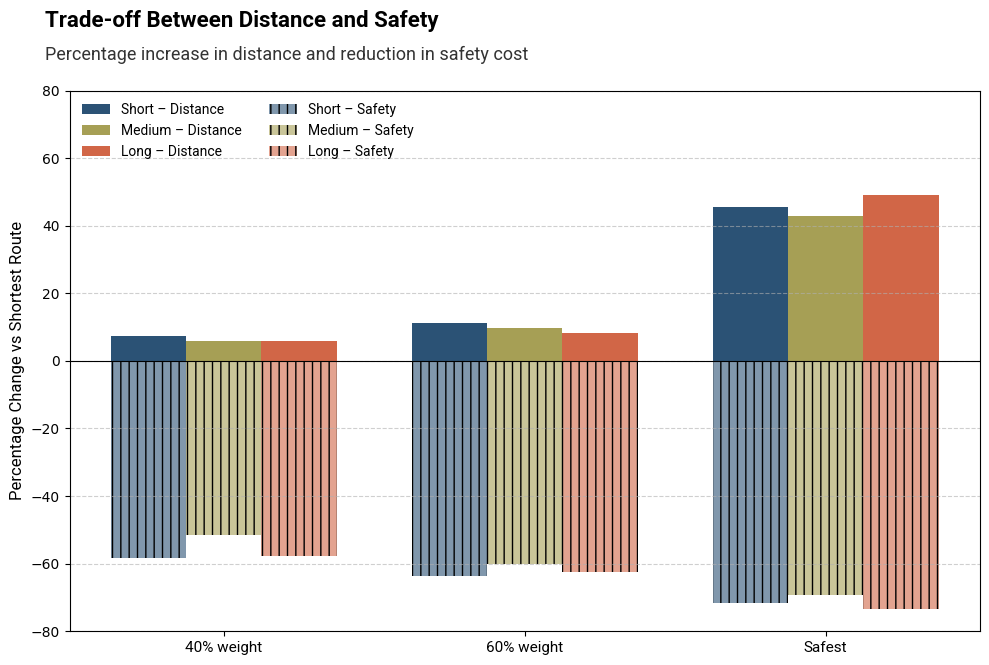

In [ ]:
weights = ["40% weight", "60% weight", "Safest"]

x = np.arange(len(weights))

dist_short  = [7.30, 11.34, 45.58]
dist_medium = [5.93, 9.82, 42.75]
dist_long   = [5.92, 8.22, 49.18]

safety_short  = [-58.38, -63.53, -71.52]
safety_medium = [-51.51, -60.22, -69.19]
safety_long   = [-57.84, -62.58, -73.40]

bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width, dist_short,  width=bar_width, color="#2B5275FF",    label="Short – Distance")
ax.bar(x,             dist_medium, width=bar_width, color="#A69F55FF", label="Medium – Distance")
ax.bar(x + bar_width, dist_long,   width=bar_width, color="#D16647FF",   label="Long – Distance")

ax.bar(x - bar_width, safety_short,  width=bar_width, color="#2B5275FF",   alpha=0.6, hatch="||", label="Short – Safety")
ax.bar(x,             safety_medium, width=bar_width, color="#A69F55FF",   alpha=0.6, hatch="||", label="Medium – Safety")
ax.bar(x + bar_width, safety_long,   width=bar_width, color="#D16647FF", alpha=0.6, hatch="||", label="Long – Safety")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_ylim(-80, 80)
ax.set_ylabel("Percentage Change vs Shortest Route", fontproperties=regular, fontsize=12)
ax.set_xticklabels(weights, fontproperties=regular, fontsize=11)
ax.legend(loc="upper left", fontsize=10, ncol=2, frameon=False, prop=regular)
ax.grid(True, linestyle="--", alpha=0.6, axis="y")

fig.text(
    0.05, 1.1,
    "Trade-off Between Distance and Safety",
    font=bold, size=16, weight=520, ha="left", va="top"
)

fig.text(
    0.05, 1.04,
    "Percentage increase in distance and reduction in safety cost",
    font=regular, size=13, ha="left", va="top", color="#333333"
)

plt.tight_layout()
plt.savefig("trade_off.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()